<a href="https://www.kaggle.com/code/janmartins/dv-datasetindiahousing?scriptVersionId=226344083" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Nesse notebook, fazemos:

Análises exploratórias sobre um conjunto de dados de habitação na Índia.

**Correlação entre variáveis**:
Foi analisada a correlação entre variáveis numéricas.
Correlações entre 0.5 e 0.9 foram destacadas, sugerindo relações moderadas a fortes entre certos fatores e o preço dos imóveis.

**Visualizações**:
Foram gerados diagramas de dispersão para visualizar a relação entre tipo de propriedade, preço e estado.
A coloração por estado ajuda a entender variações geográficas nos preços.

**Análises de Preço**:
O preço médio por estado e cidade foi calculado.
Identificação dos estados mais acessíveis e do tipo de propriedade mais comum.

**histogramas e boxplots**:
Para visualizar a distribuição de preços por região e tipo de propriedade.

**Machine Learning**:
Para classificar as informações contidas na coluna Availability_Status.

In [1]:
# Importando as bibliotecas que vamos usar nessa análise

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/india-house-price-prediction/india_housing_prices.csv


# Info dataset

In [2]:
# Importando o dataset e apresentando as primeiras cinco linhas

df_india_housing = pd.read_csv("/kaggle/input/india-house-price-prediction/india_housing_prices.csv")
df_india_housing.head()

,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [3]:
# Apresentando as informações do dataset, nomes das colunas, quais os tipos de dados em cada coluna e a quantidade de linhas

df_india_housing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  object 
 2   City                            250000 non-null  object 
 3   Locality                        250000 non-null  object 
 4   Property_Type                   250000 non-null  object 
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  object 
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors    

In [4]:
# A coluna ID so tem uma númeração para registro das casas, vamos nos livrar dessa coluna

df_india_housing.drop(['ID'], axis=1, inplace=True)

In [5]:
# Verificamos a soma das linhas nulas por cada coluna que temos no dataset

df_india_housing.isnull().sum()

State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

# Correlação

In [6]:
# Vamos olhar para os números e gerar uma tabela para saber se temos algum tipo de 
# correlação que seja superior a 0.7 e inferior a 0.9

numeros = df_india_housing.select_dtypes(include=np.number)
corr = numeros.corr()

corr_filtrada = corr.unstack().sort_values(ascending=False)
corr_filtrada = corr_filtrada[(corr_filtrada > 0.5) & (corr_filtrada < 0.9)]


In [7]:
# Exibindo os pares de variáveis e suas correlações sem levar em conta o filtro que fizemos

print(corr)

                       BHK  Size_in_SqFt  Price_in_Lakhs  Price_per_SqFt  \
BHK               1.000000     -0.001033       -0.000980        0.001174   
Size_in_SqFt     -0.001033      1.000000       -0.002529       -0.614533   
Price_in_Lakhs   -0.000980     -0.002529        1.000000        0.555625   
Price_per_SqFt    0.001174     -0.614533        0.555625        1.000000   
Year_Built        0.000917      0.004135        0.002714       -0.001212   
Floor_No          0.001263     -0.002775       -0.001719       -0.001906   
Total_Floors     -0.002862     -0.003451        0.001283        0.004175   
Age_of_Property  -0.000917     -0.004135       -0.002714        0.001212   
Nearby_Schools   -0.000762      0.001966        0.000155       -0.000094   
Nearby_Hospitals  0.001162     -0.001695       -0.002769       -0.000145   

                  Year_Built  Floor_No  Total_Floors  Age_of_Property  \
BHK                 0.000917  0.001263     -0.002862        -0.000917   
Size_in_SqFt     

In [8]:
# Exibindo os pares de variáveis e suas correlações em forma de lista

print(corr_filtrada)

Price_per_SqFt  Price_in_Lakhs    0.555625
Price_in_Lakhs  Price_per_SqFt    0.555625
dtype: float64


# 1. Diagrama de dispersão
    * Usamos um for para percorrer quase todas as colunas

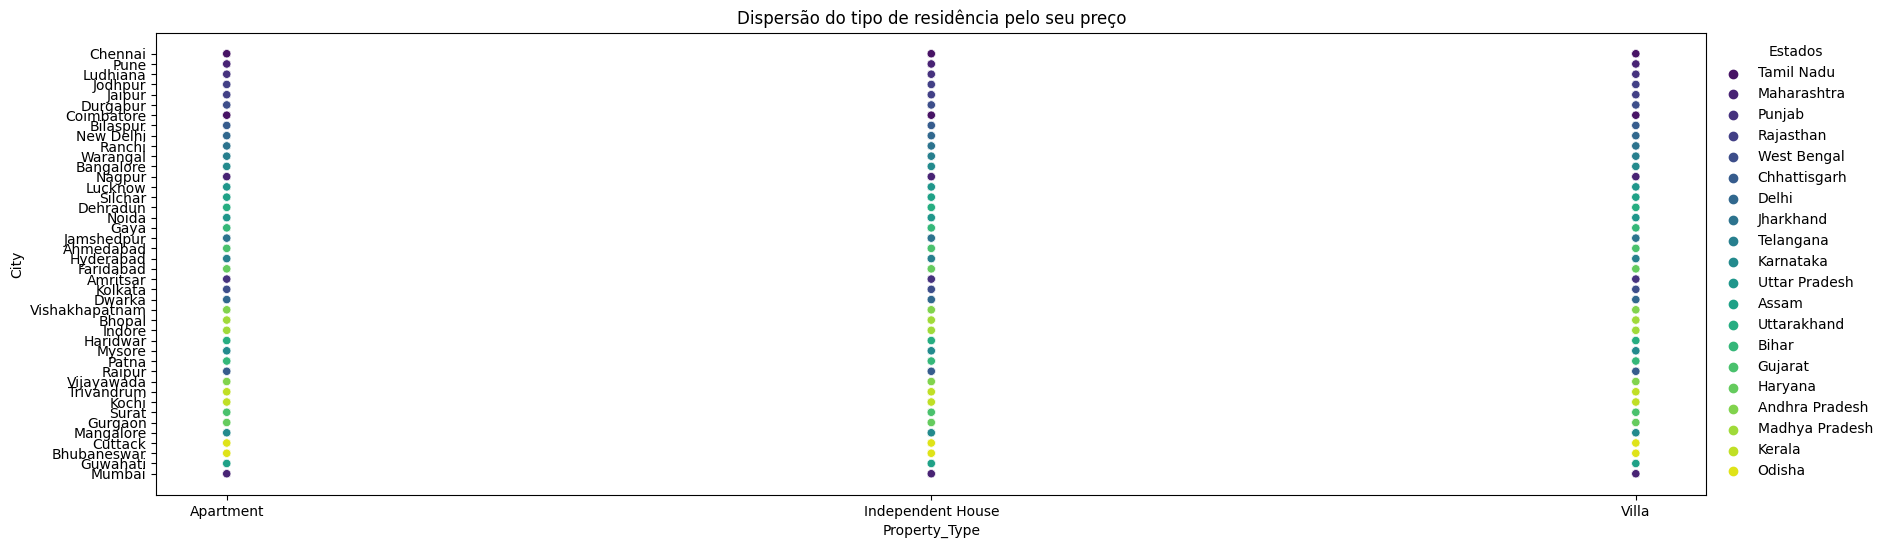

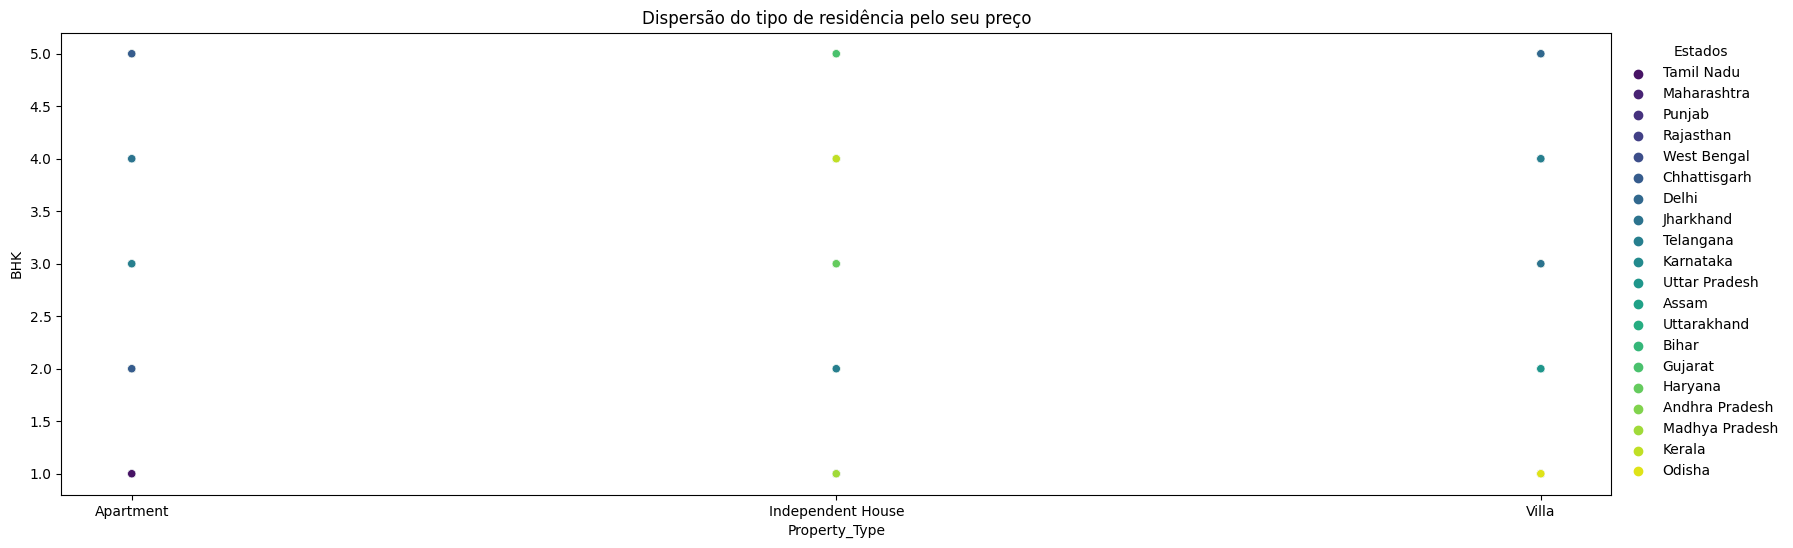

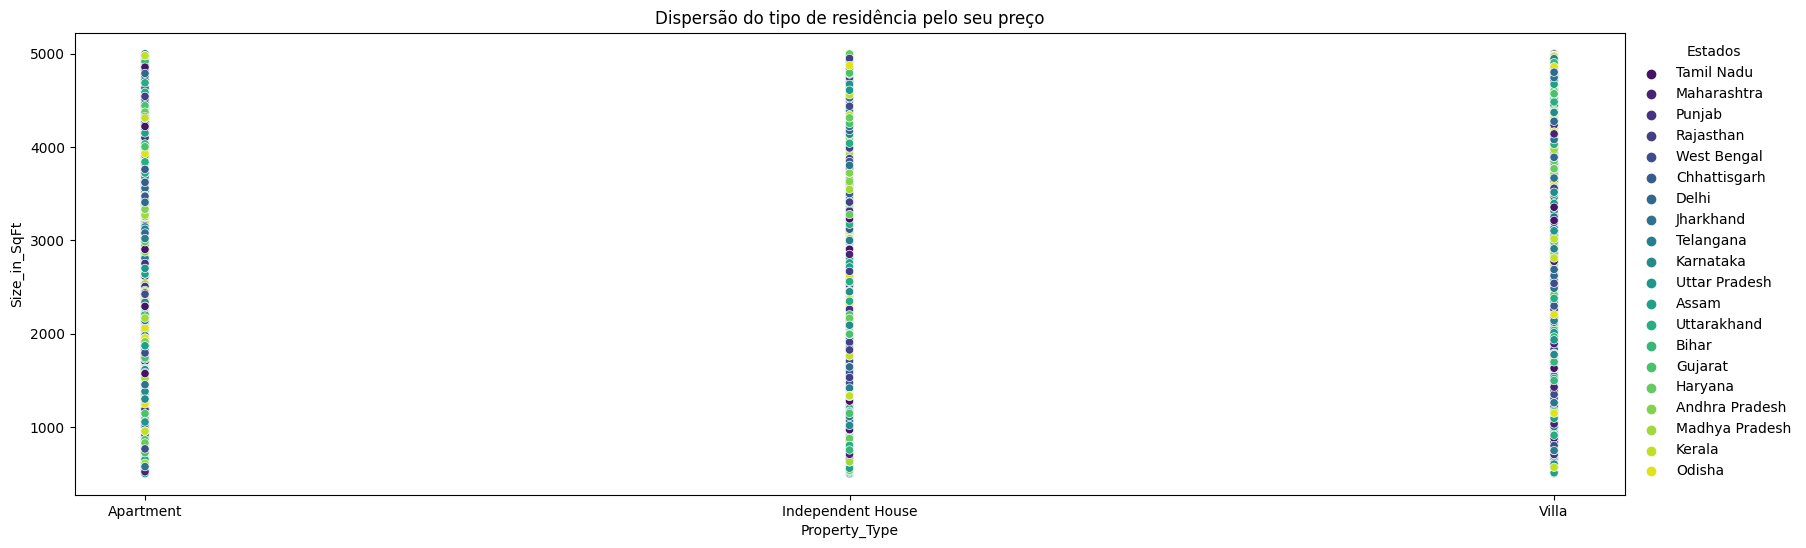

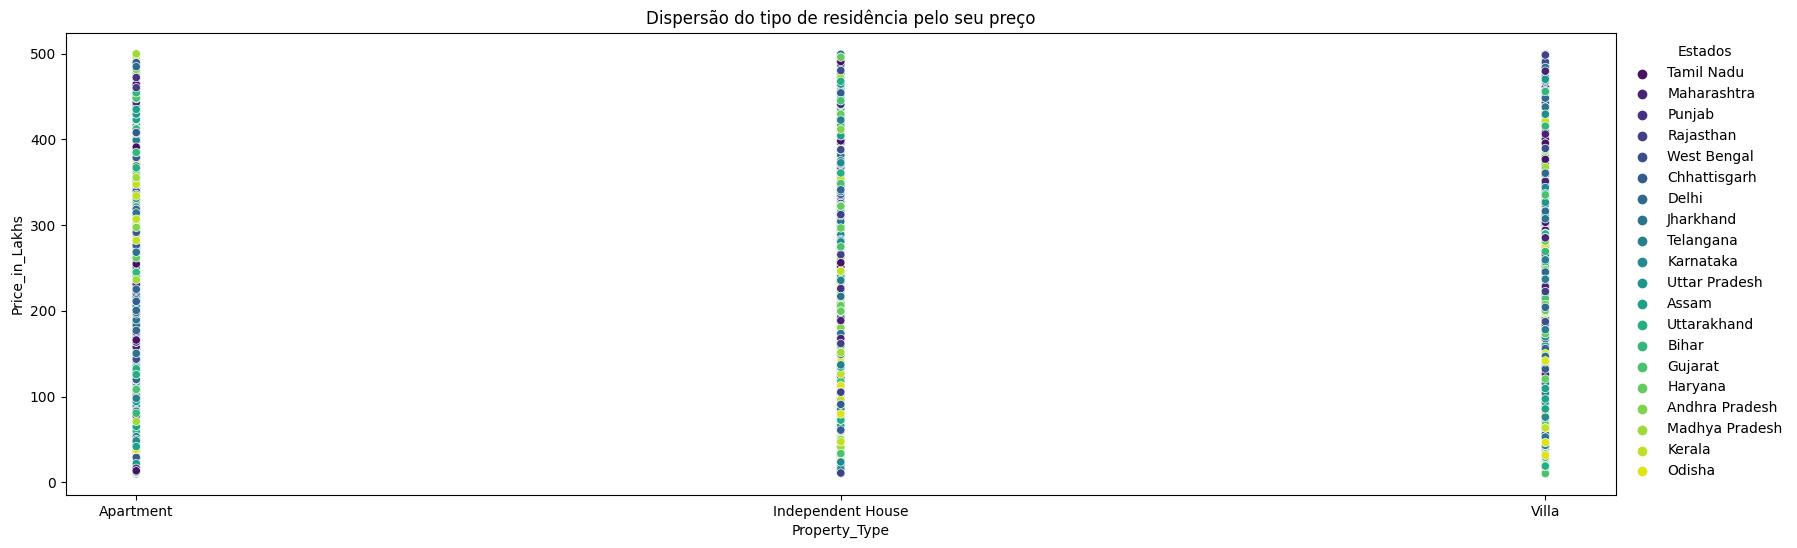

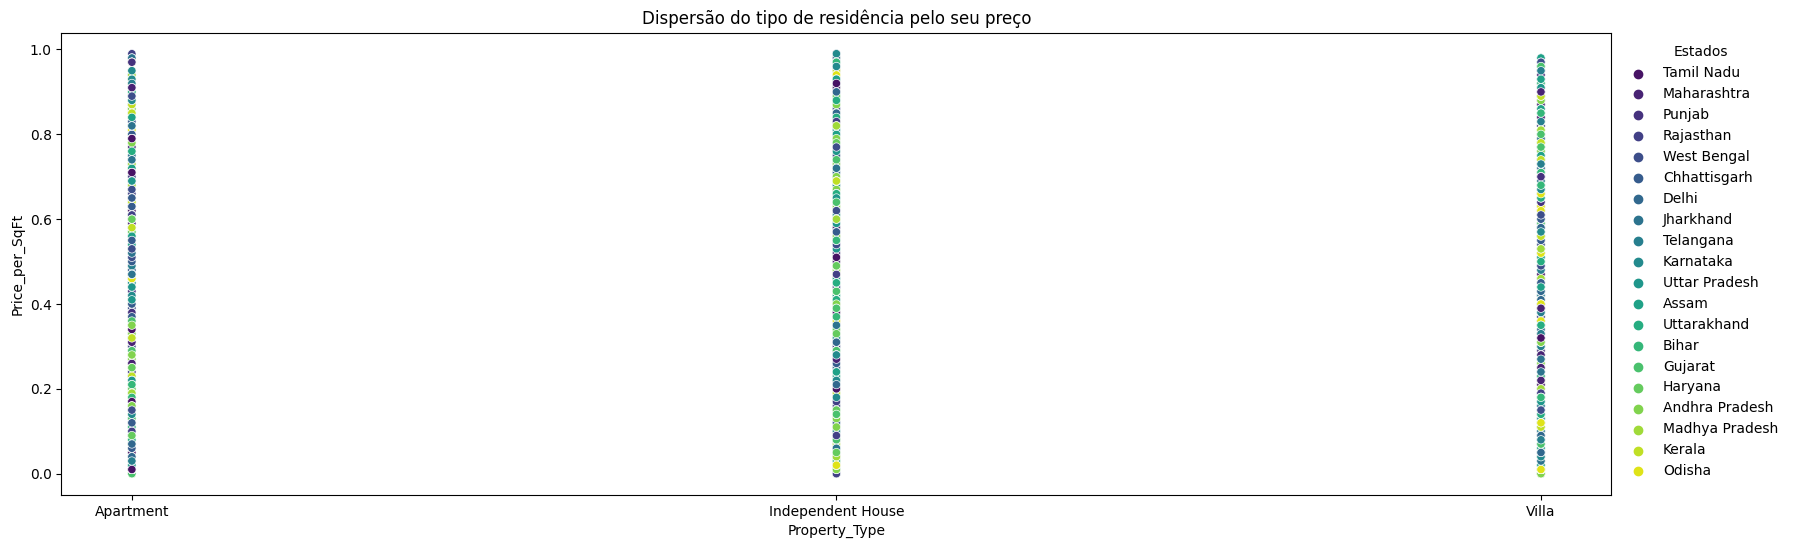

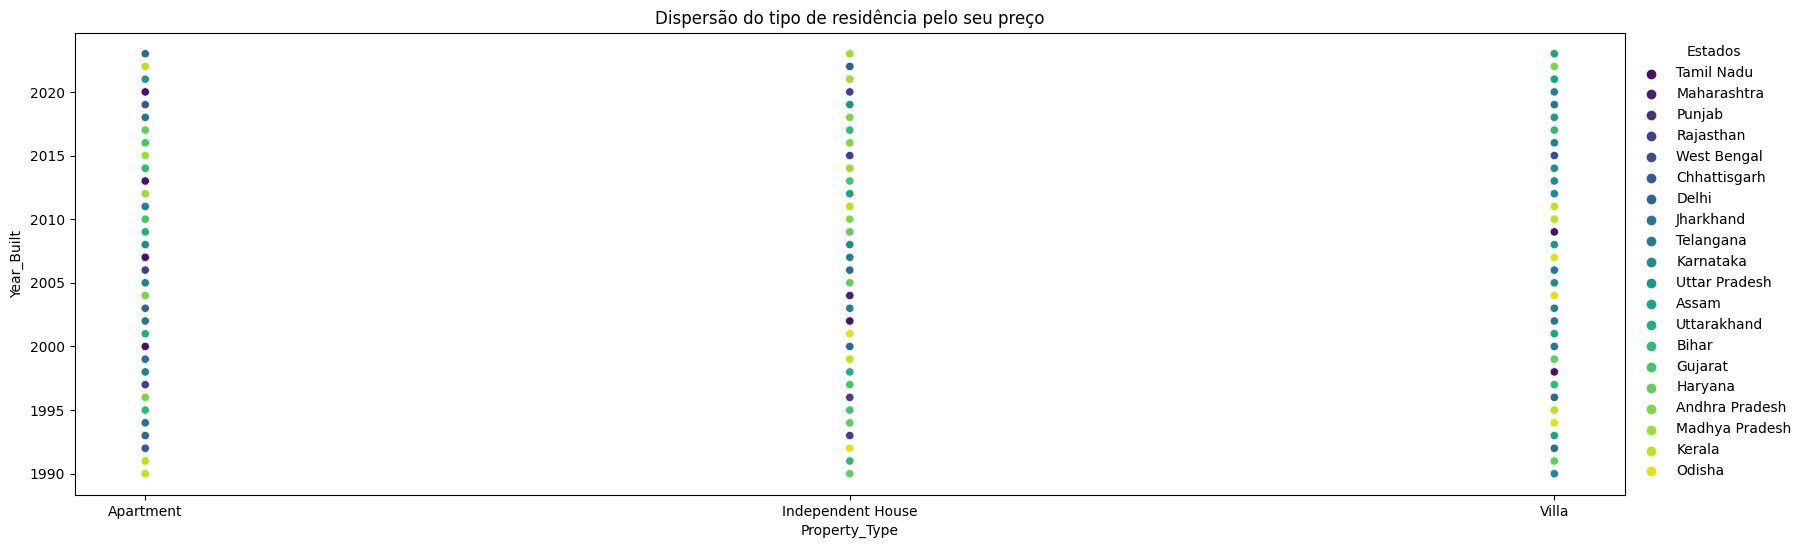

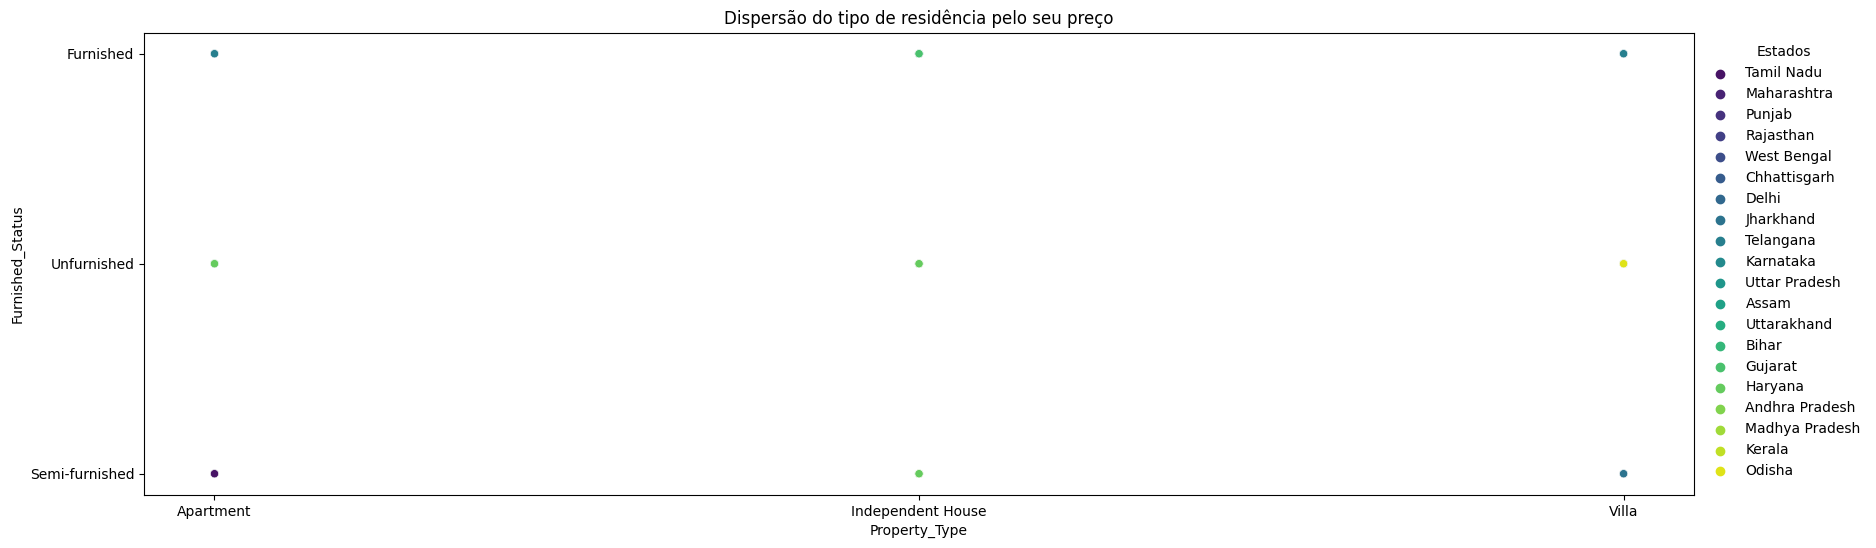

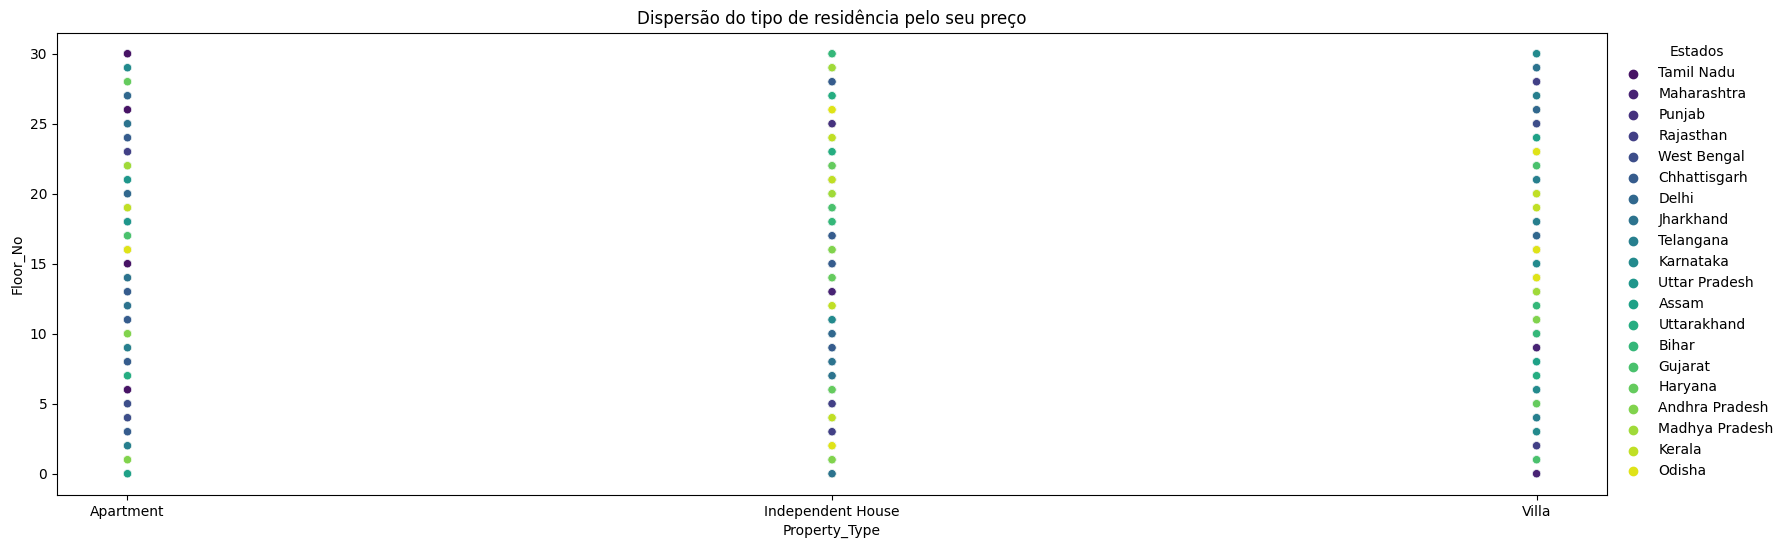

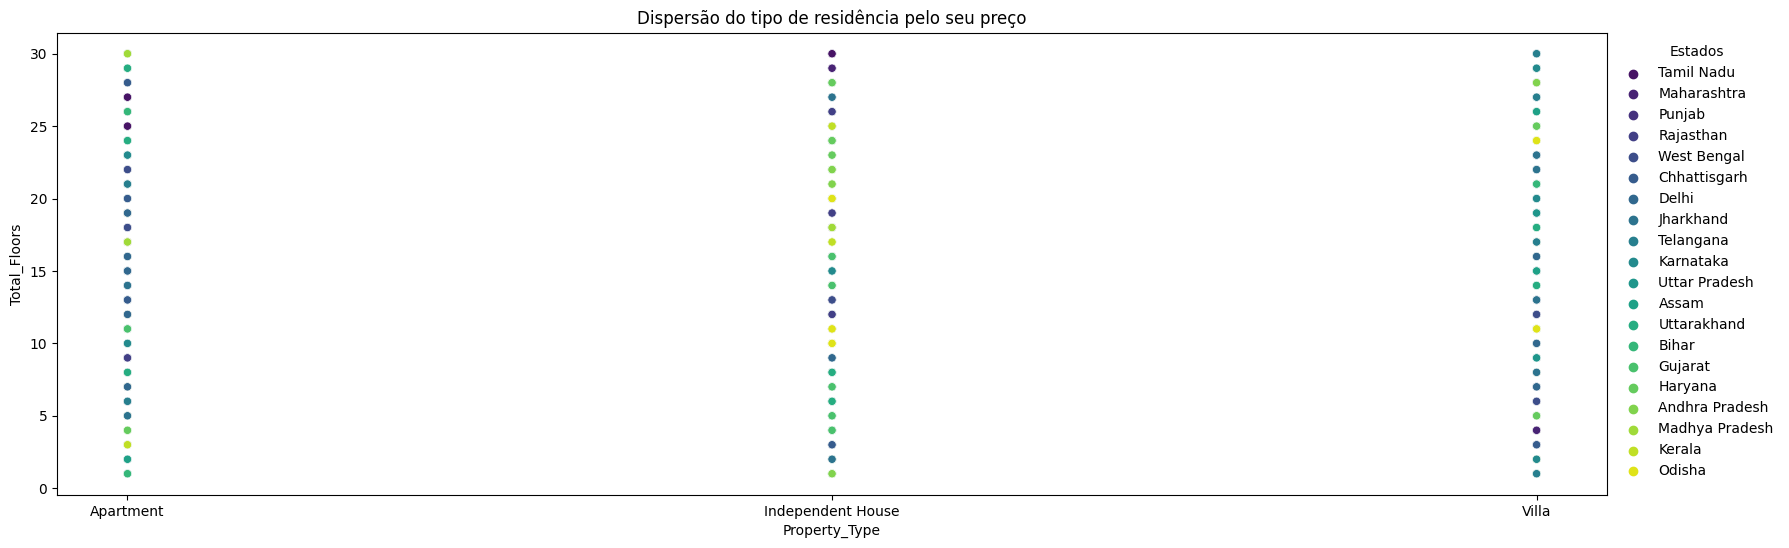

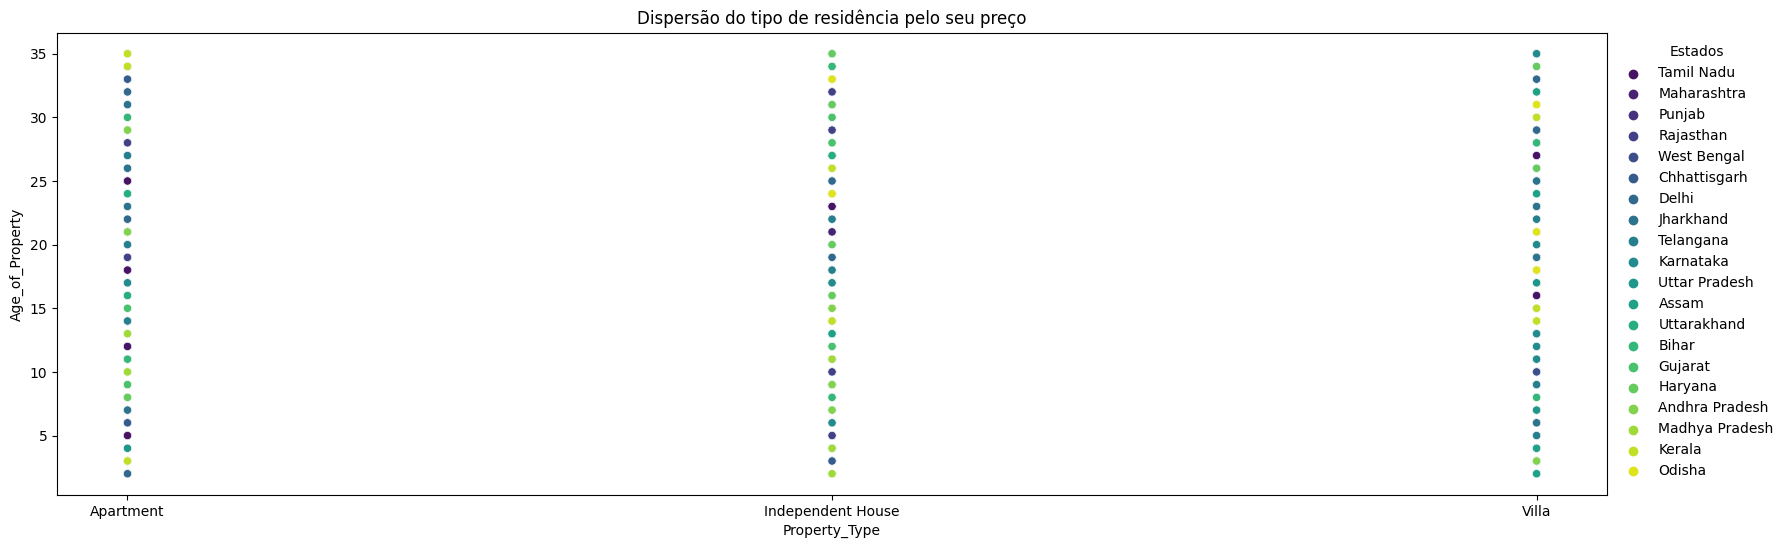

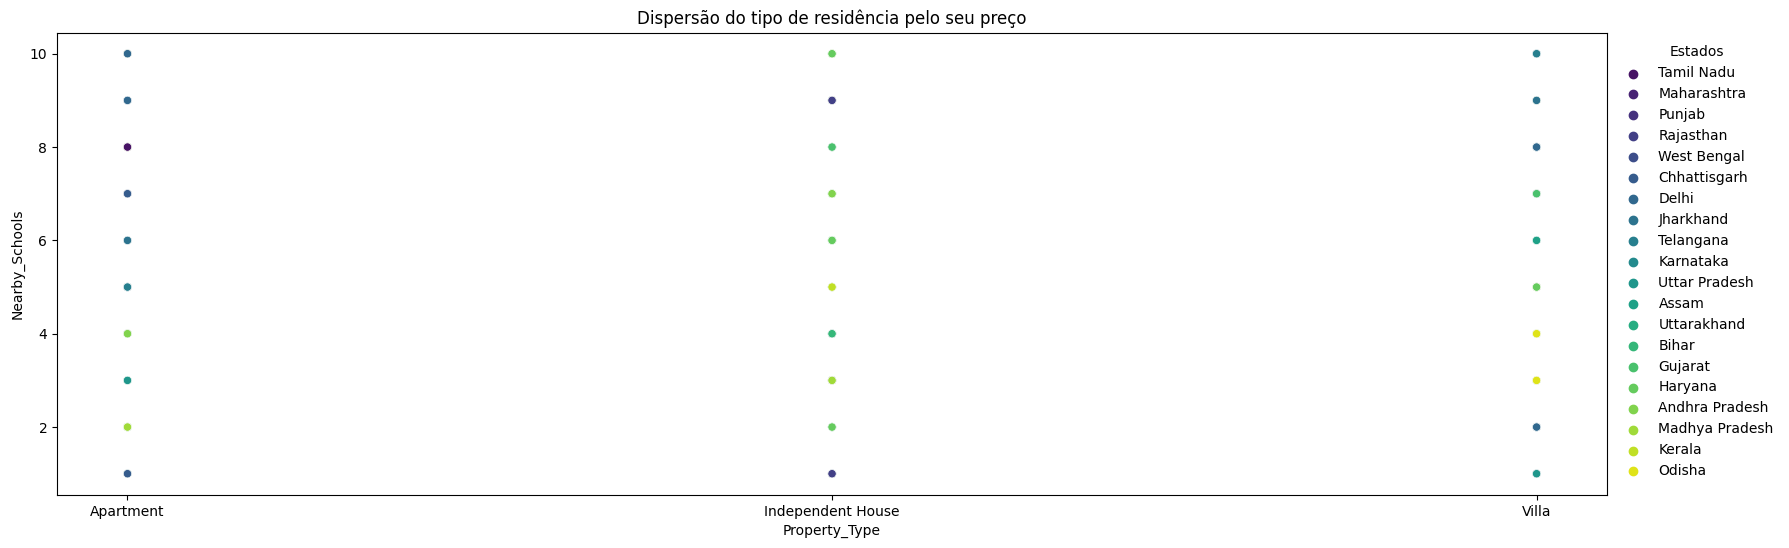

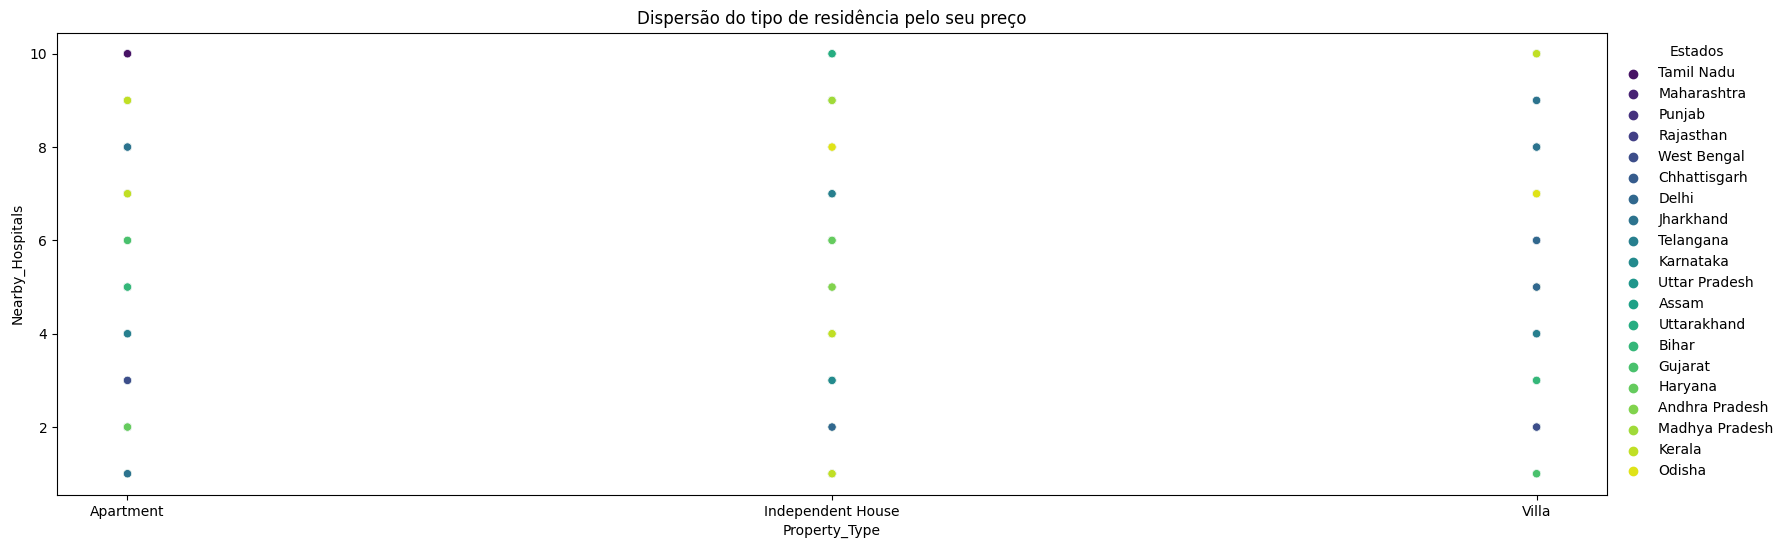

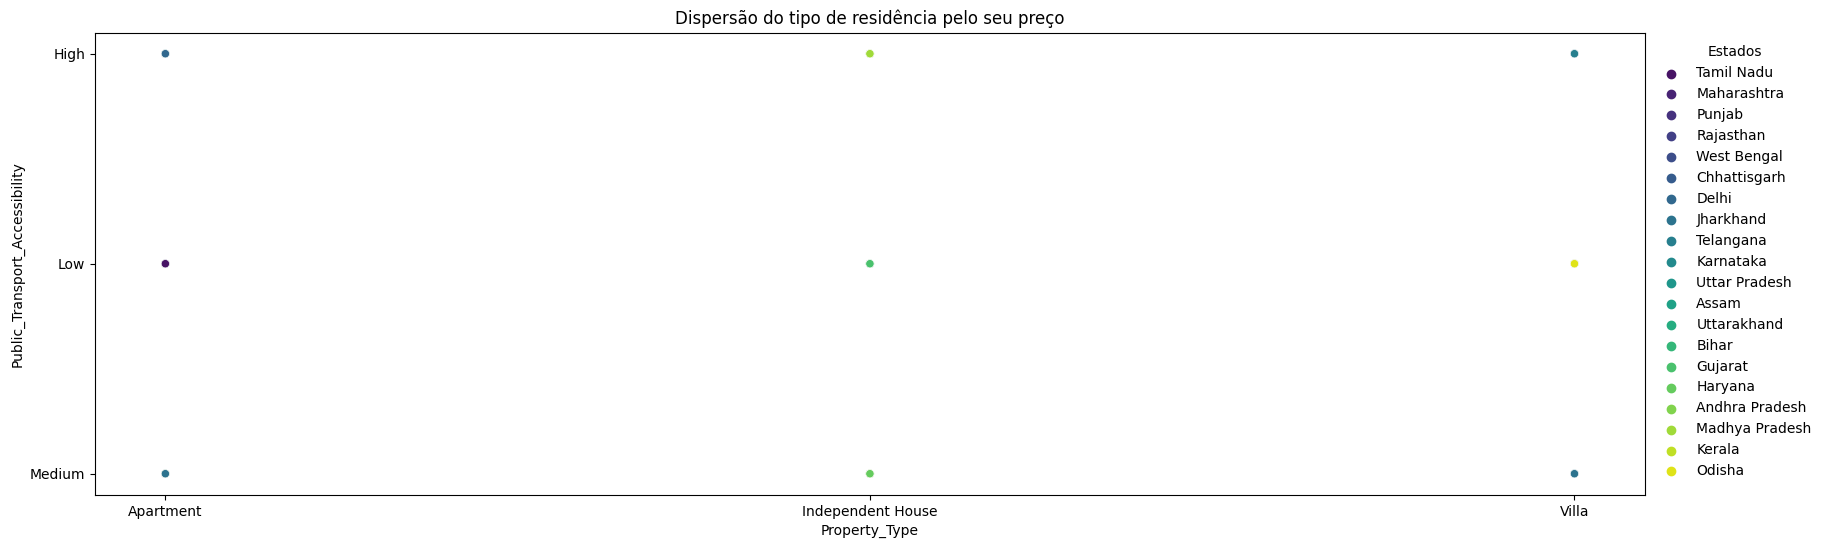

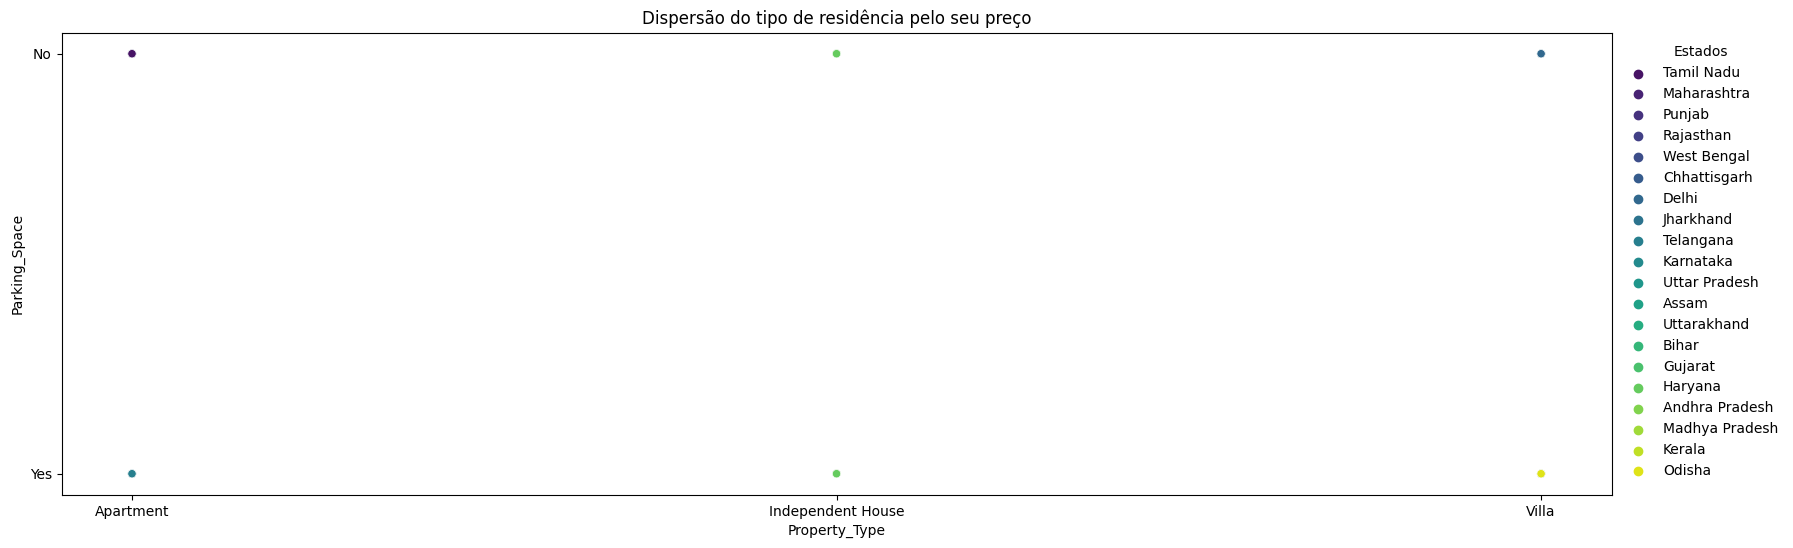

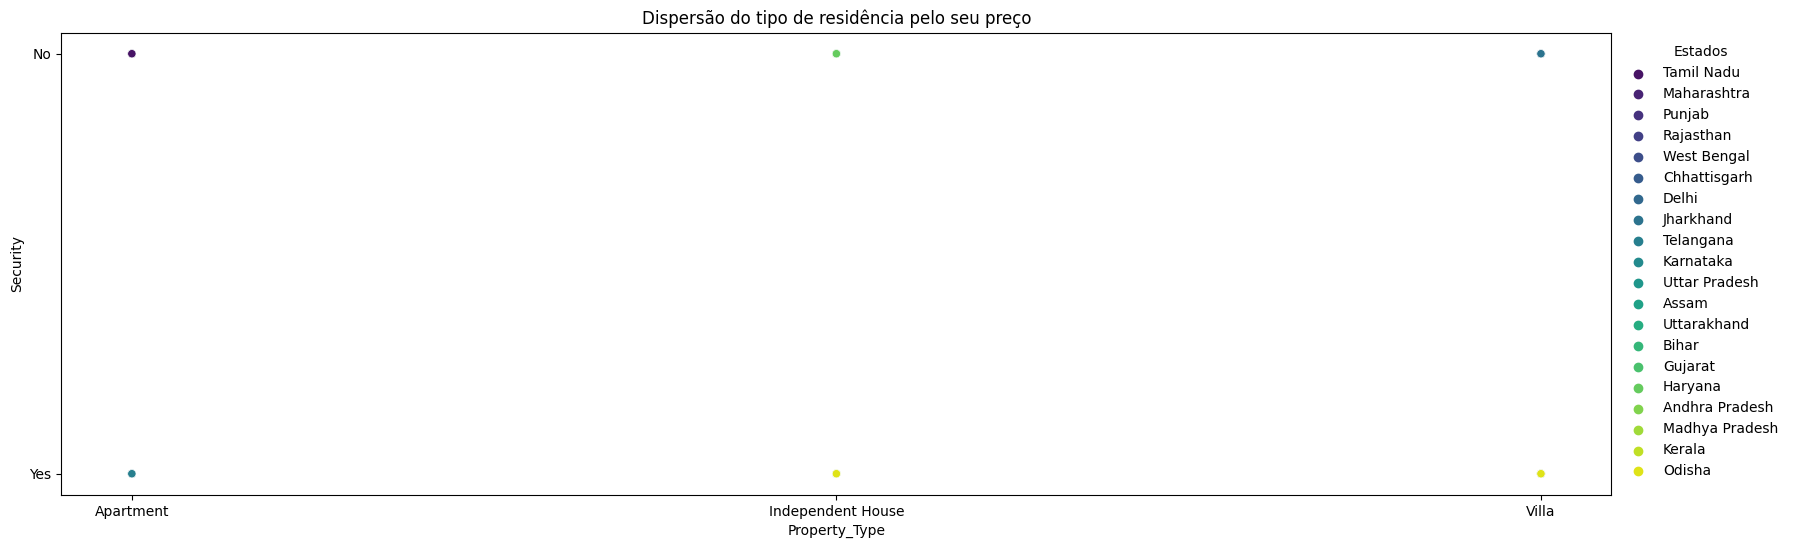

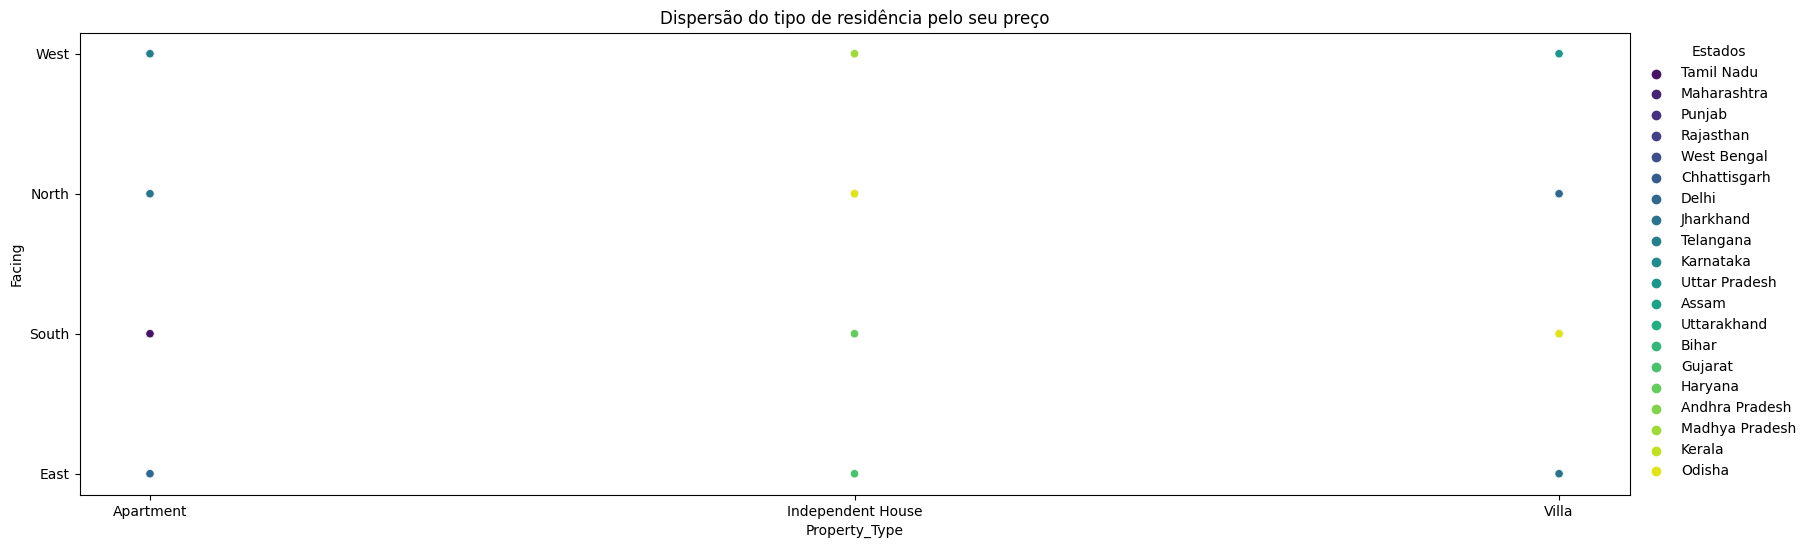

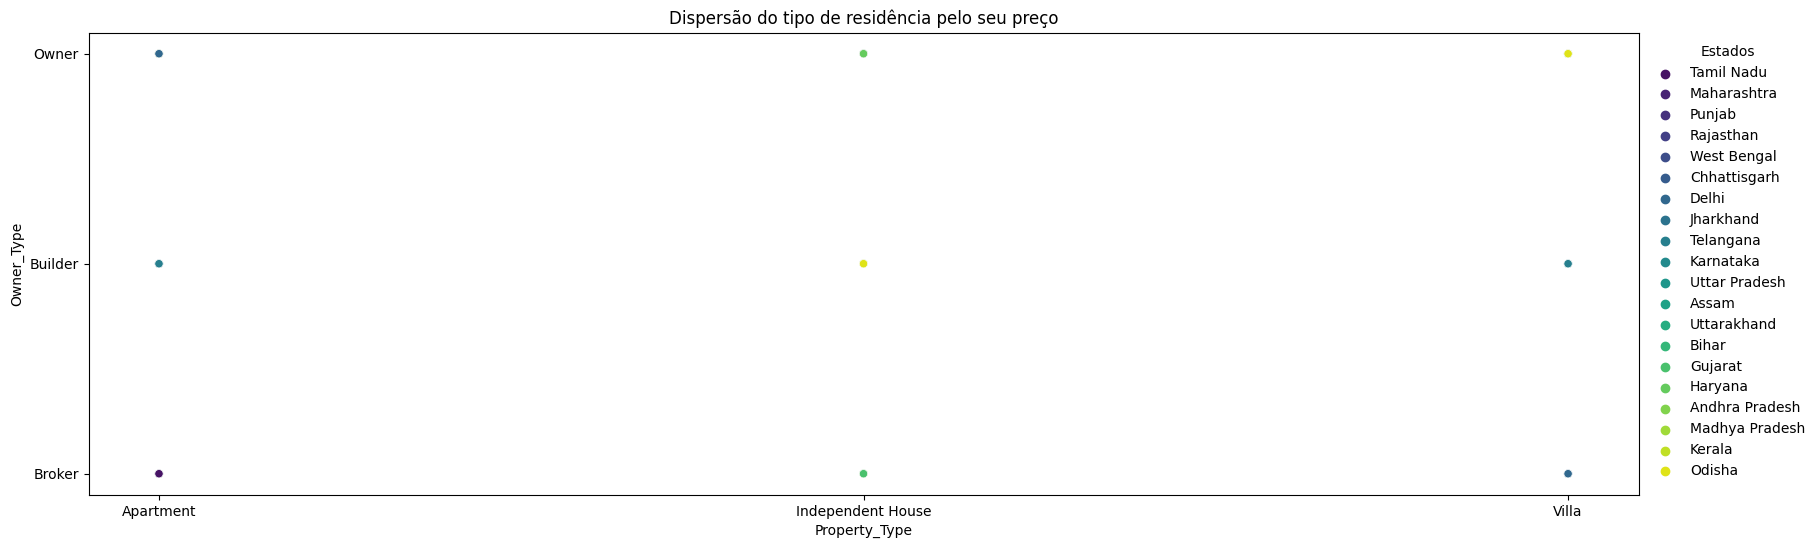

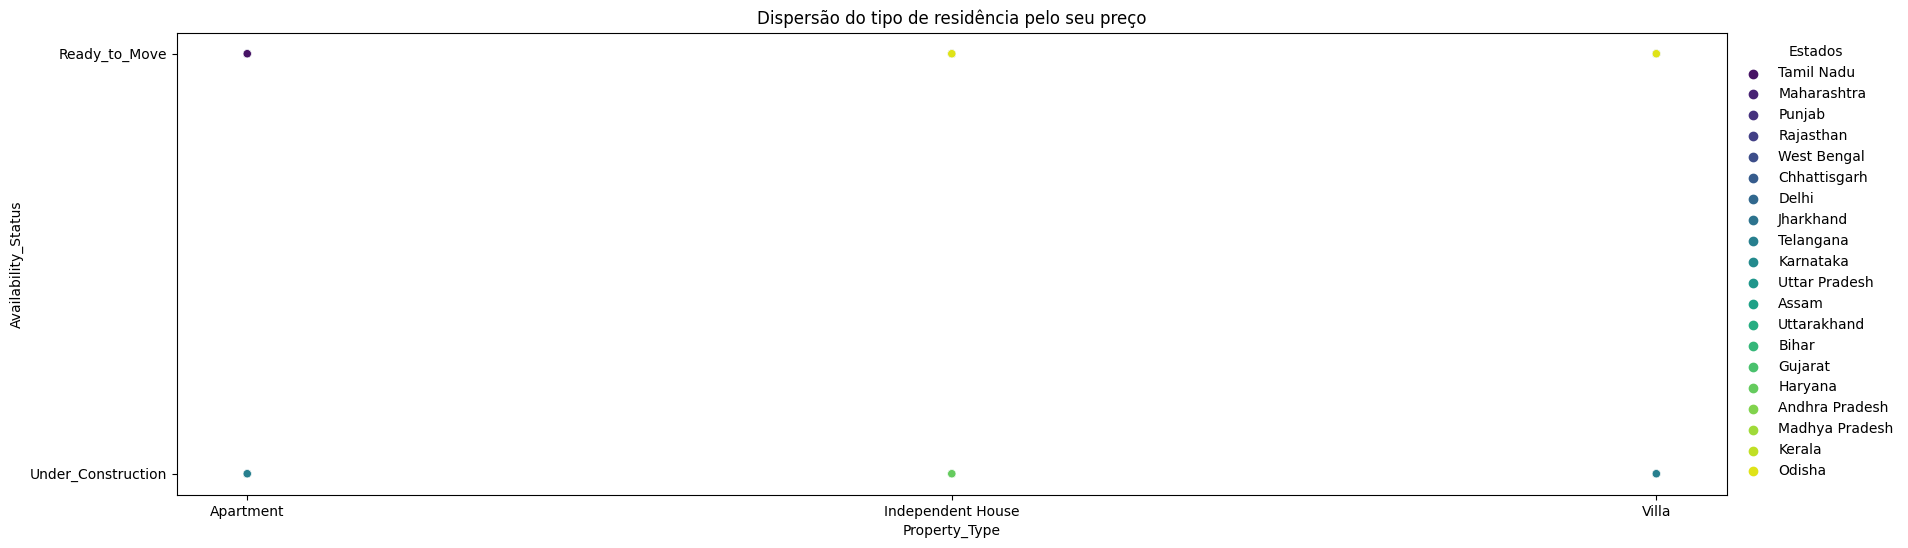

In [9]:
col_pular = ['Locality', 'Property_Type', 'State', 'Amenities']
for col in df_india_housing.columns:
    if col in col_pular:
        continue
    plt.figure(figsize=(20, 6))
    sns.scatterplot(data=df_india_housing, x='Property_Type', y=col, hue='State', palette='viridis')
    plt.title('Dispersão do tipo de residência pelo seu preço')
    plt.xlabel('Property_Type')
    plt.ylabel(f'{col}')
    plt.legend(title='Estados', loc='upper left', bbox_to_anchor=(1, 1), frameon=False, fontsize=10)
    plt.show()

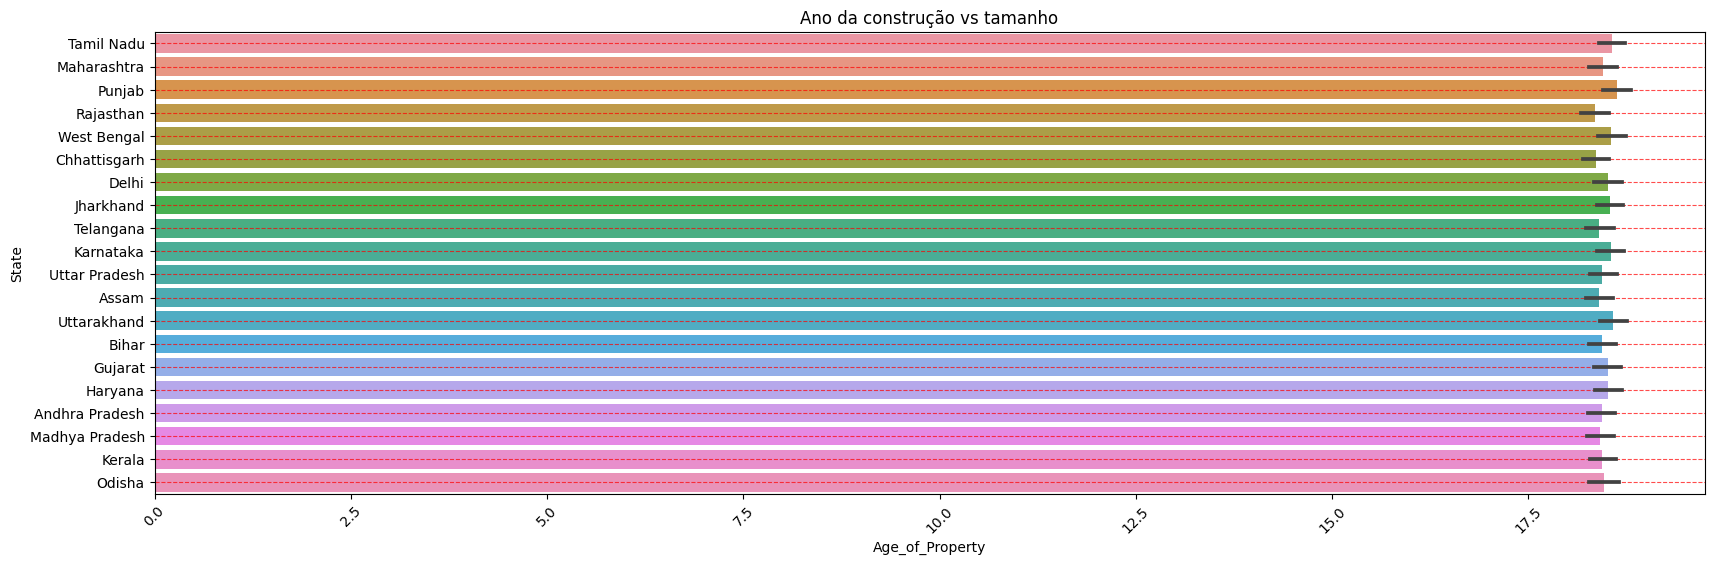

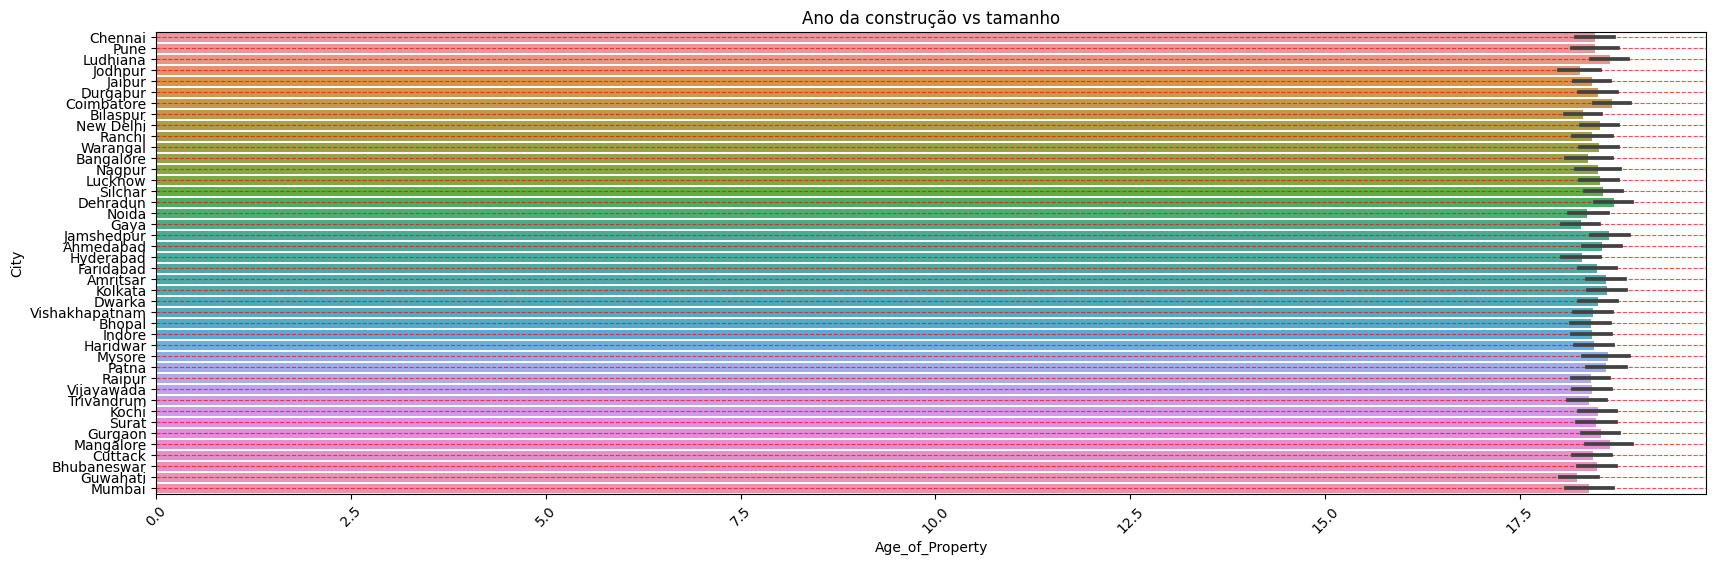

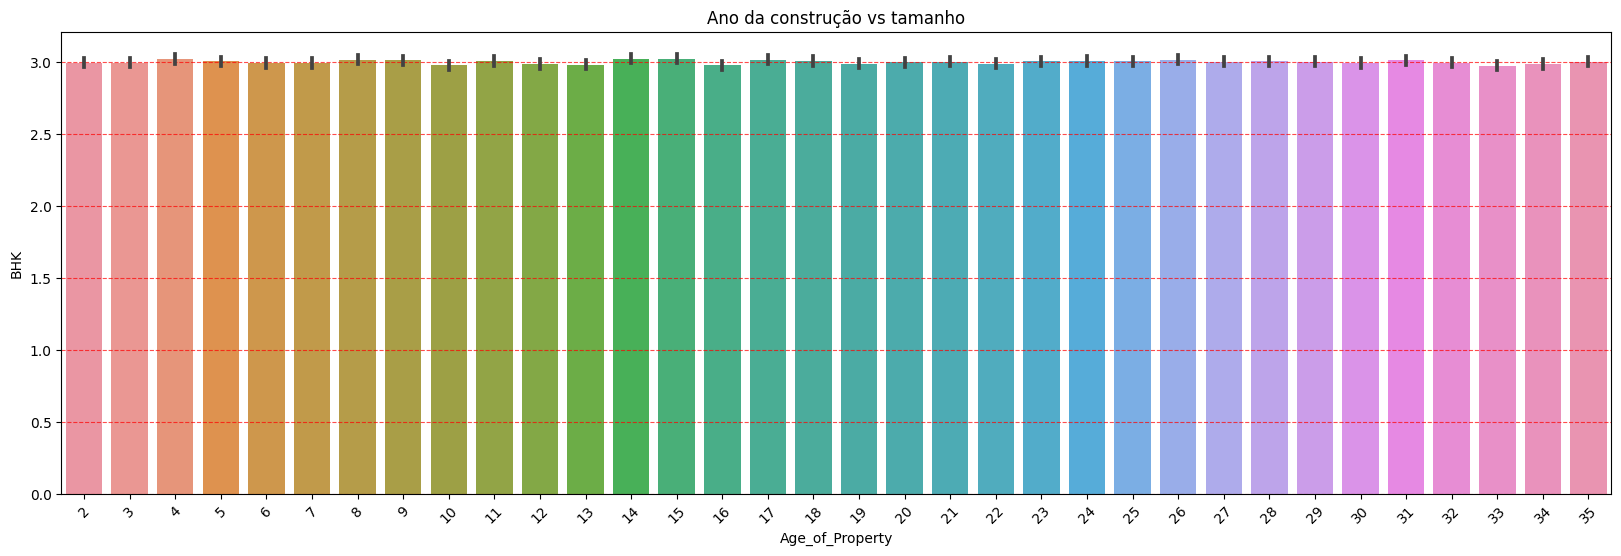

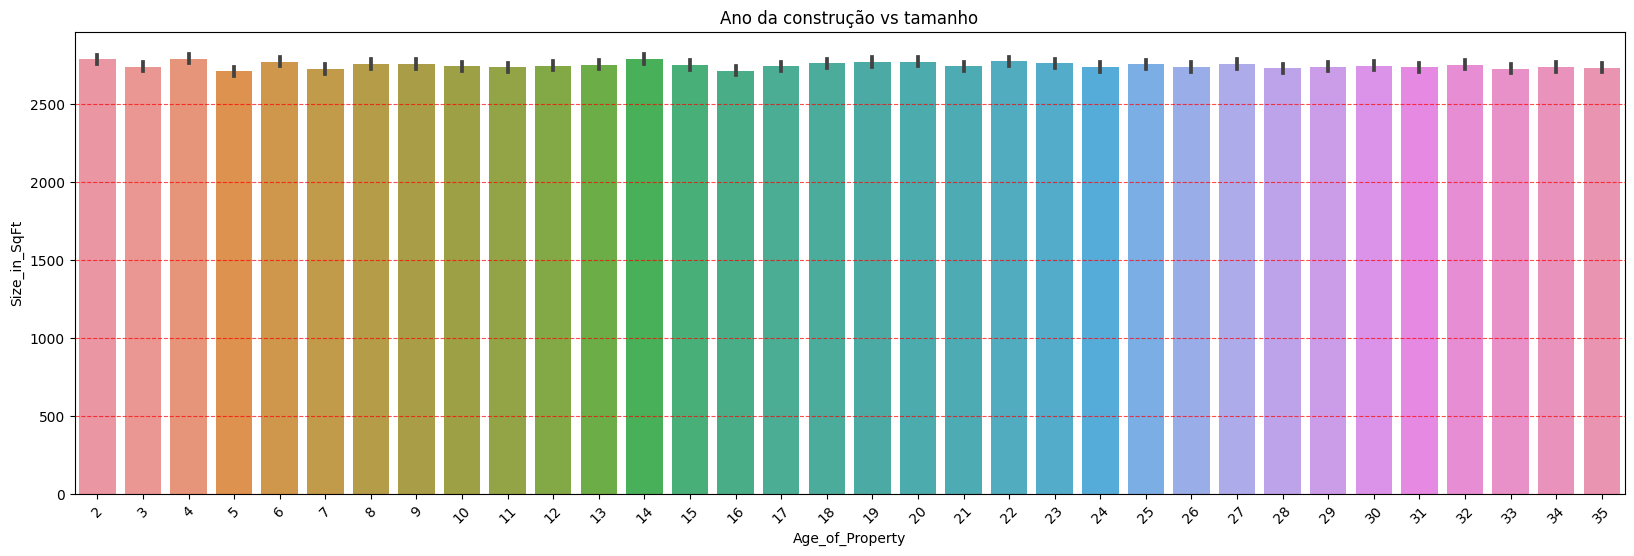

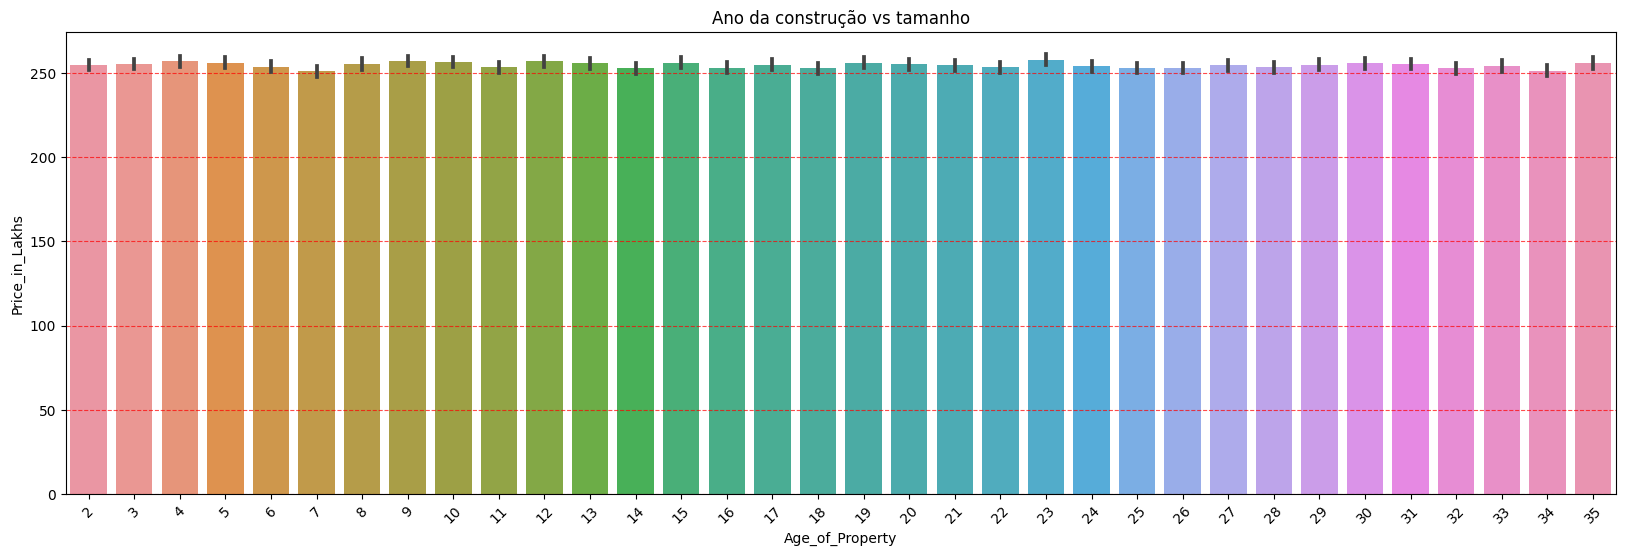

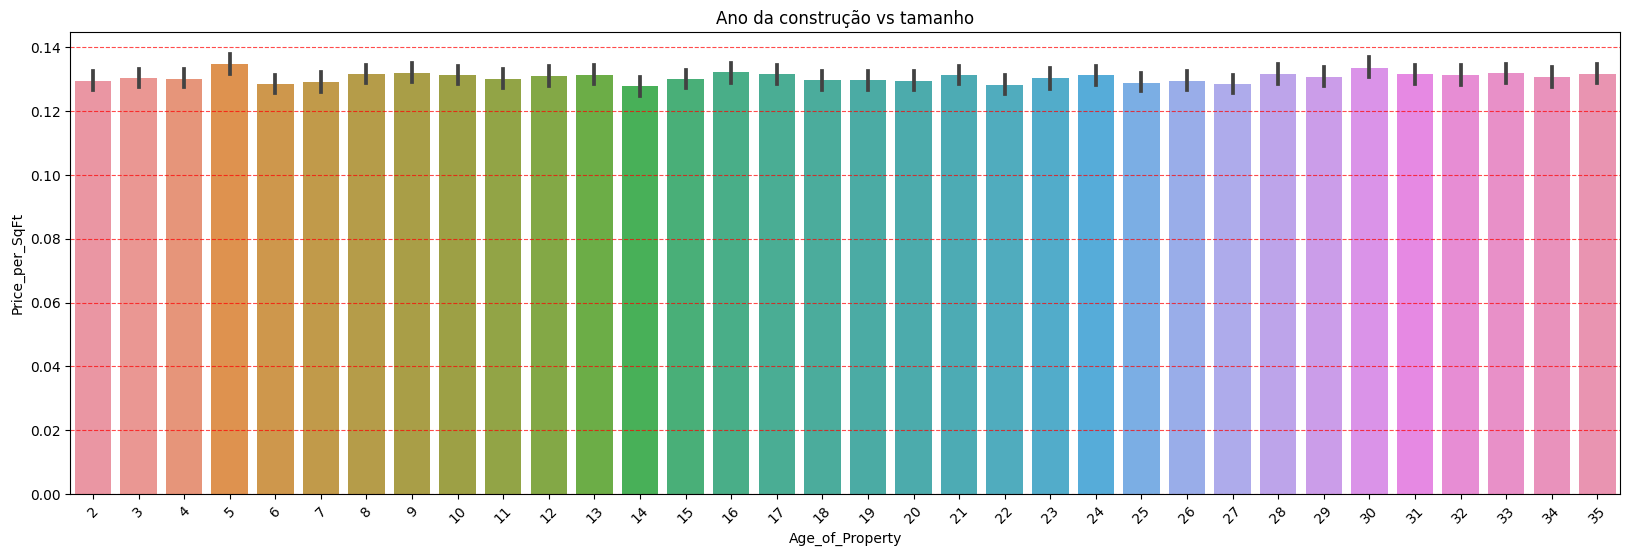

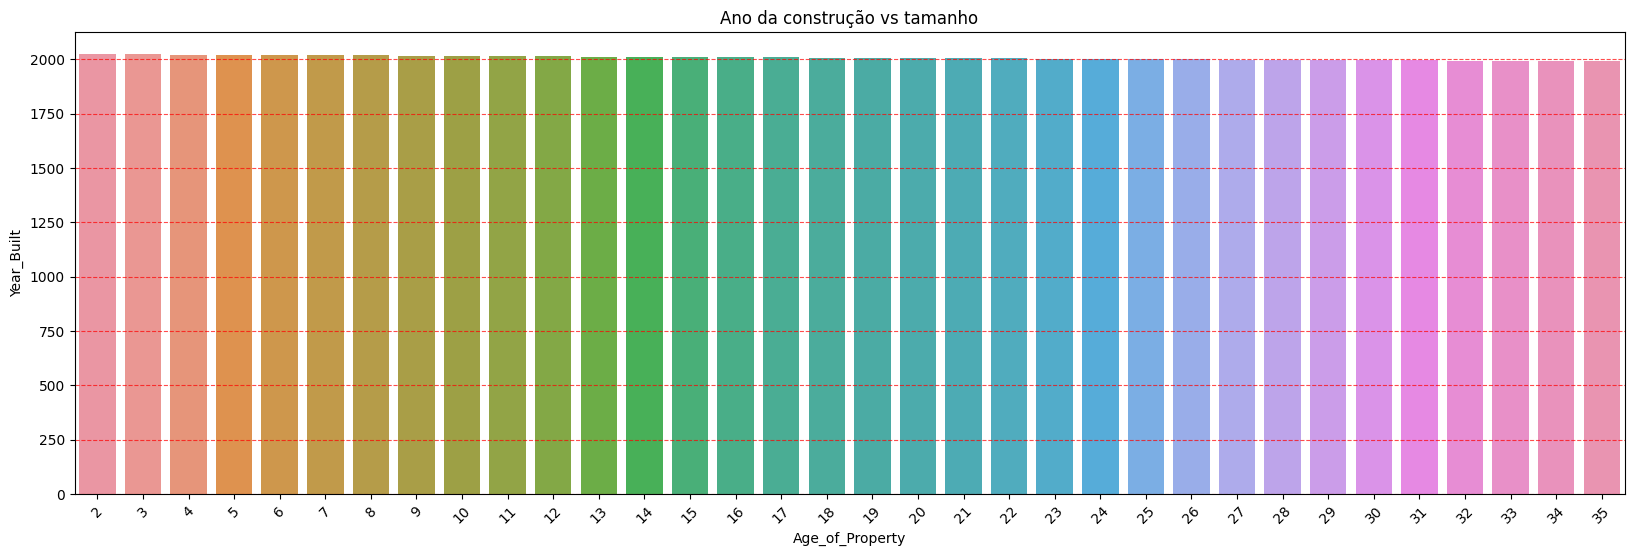

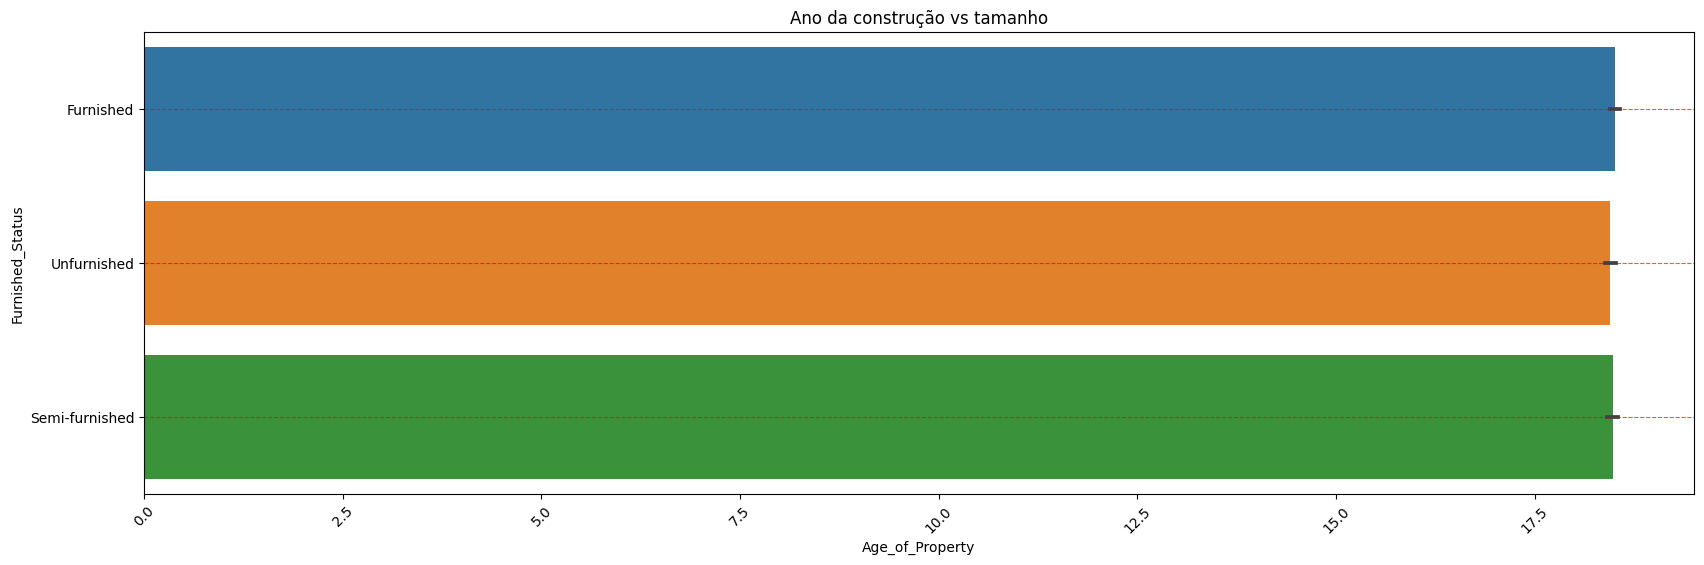

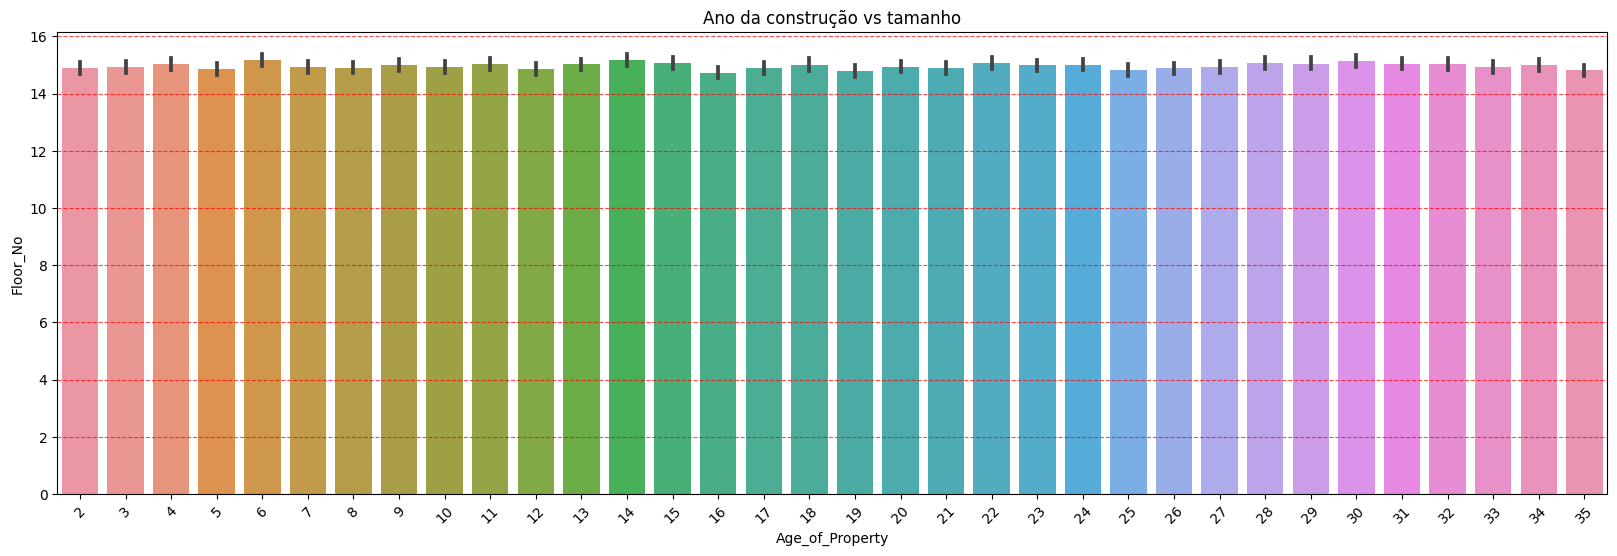

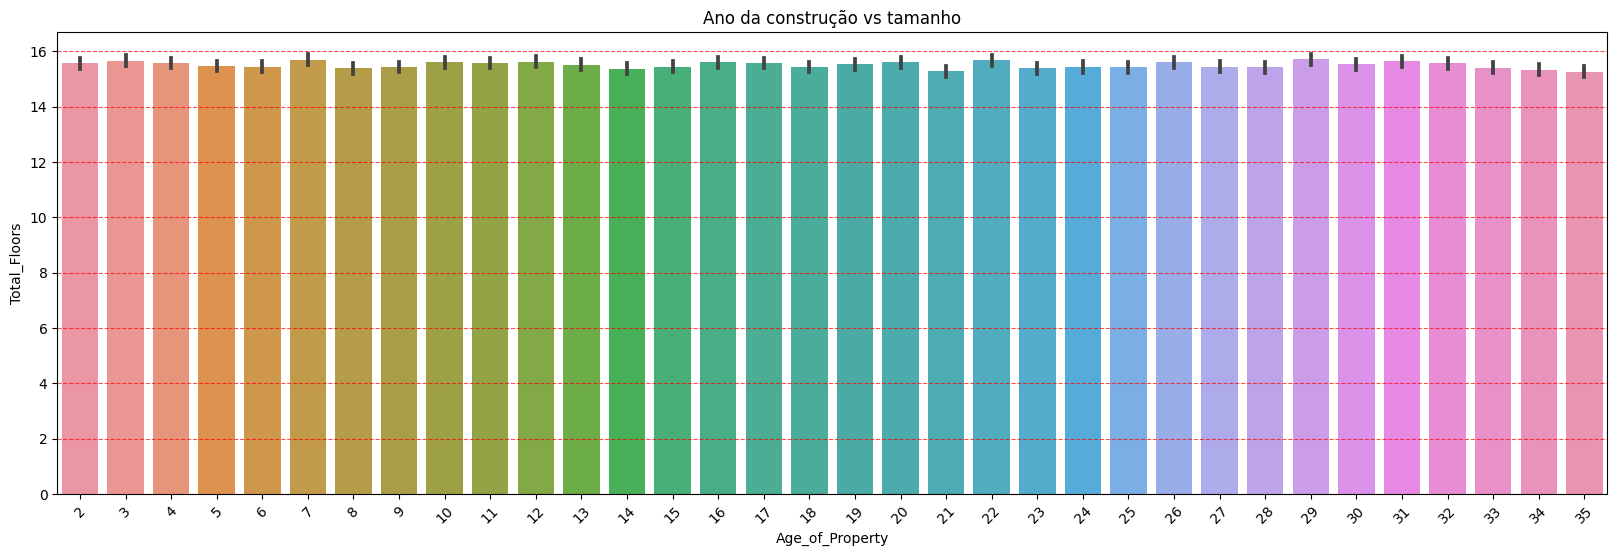

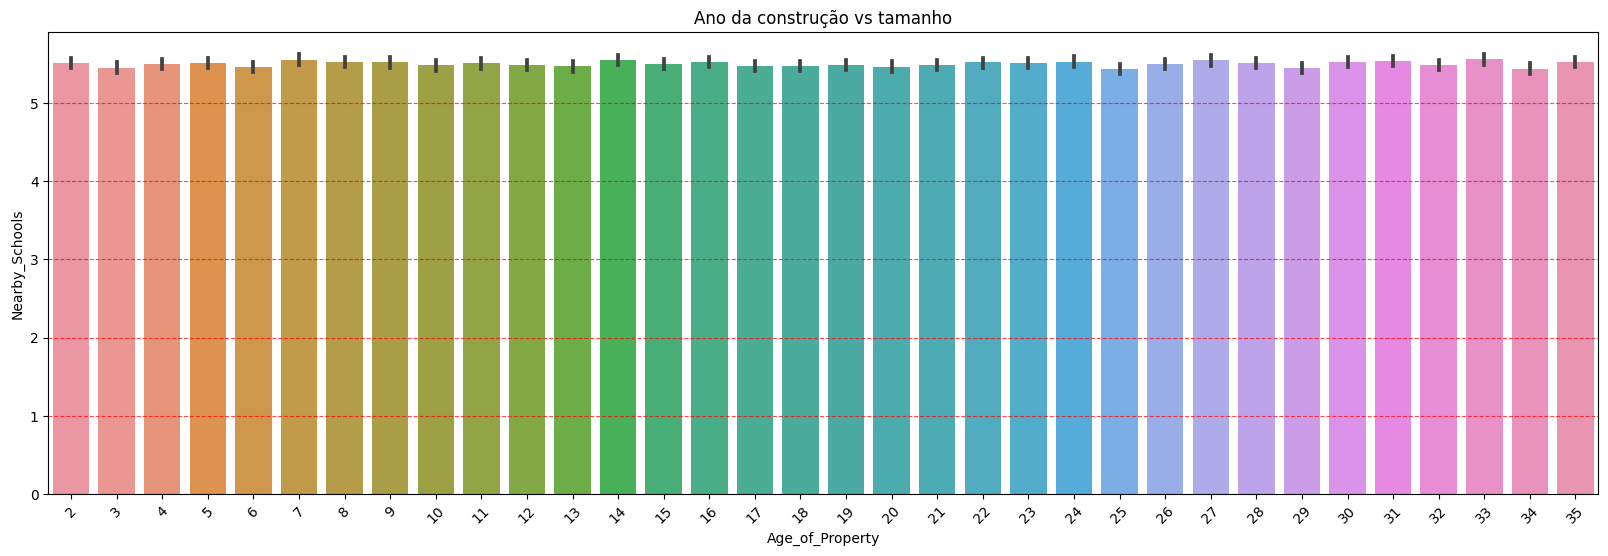

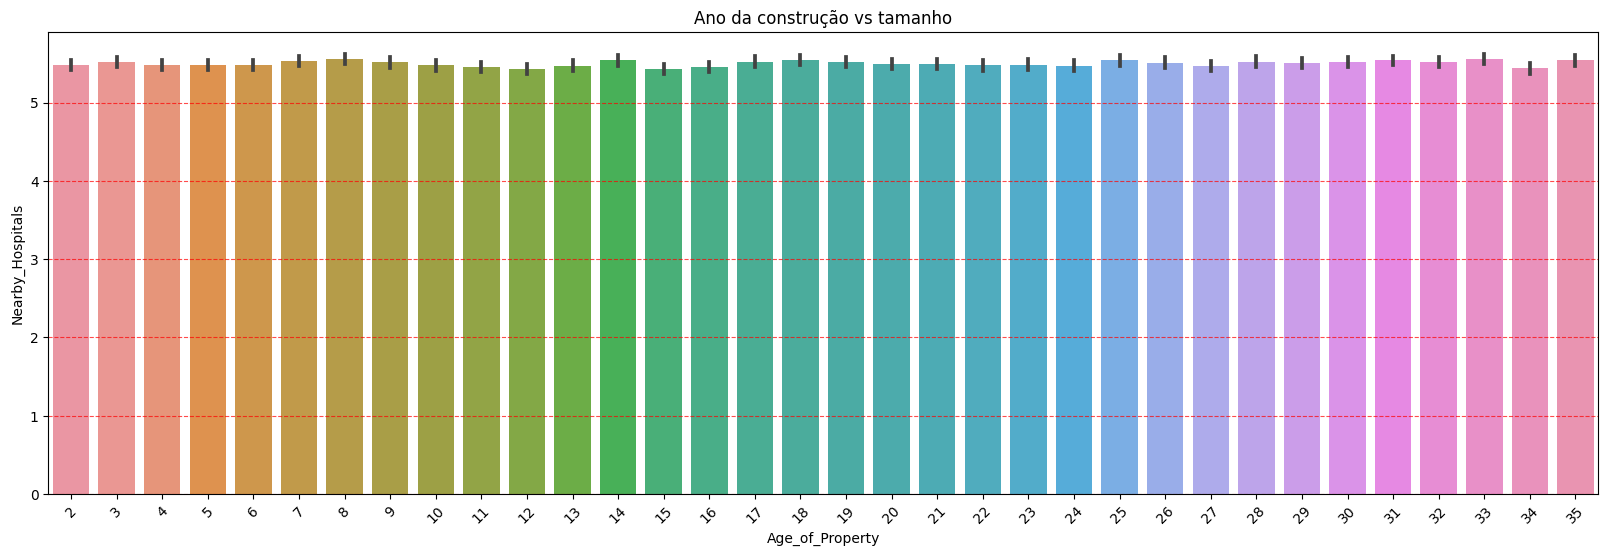

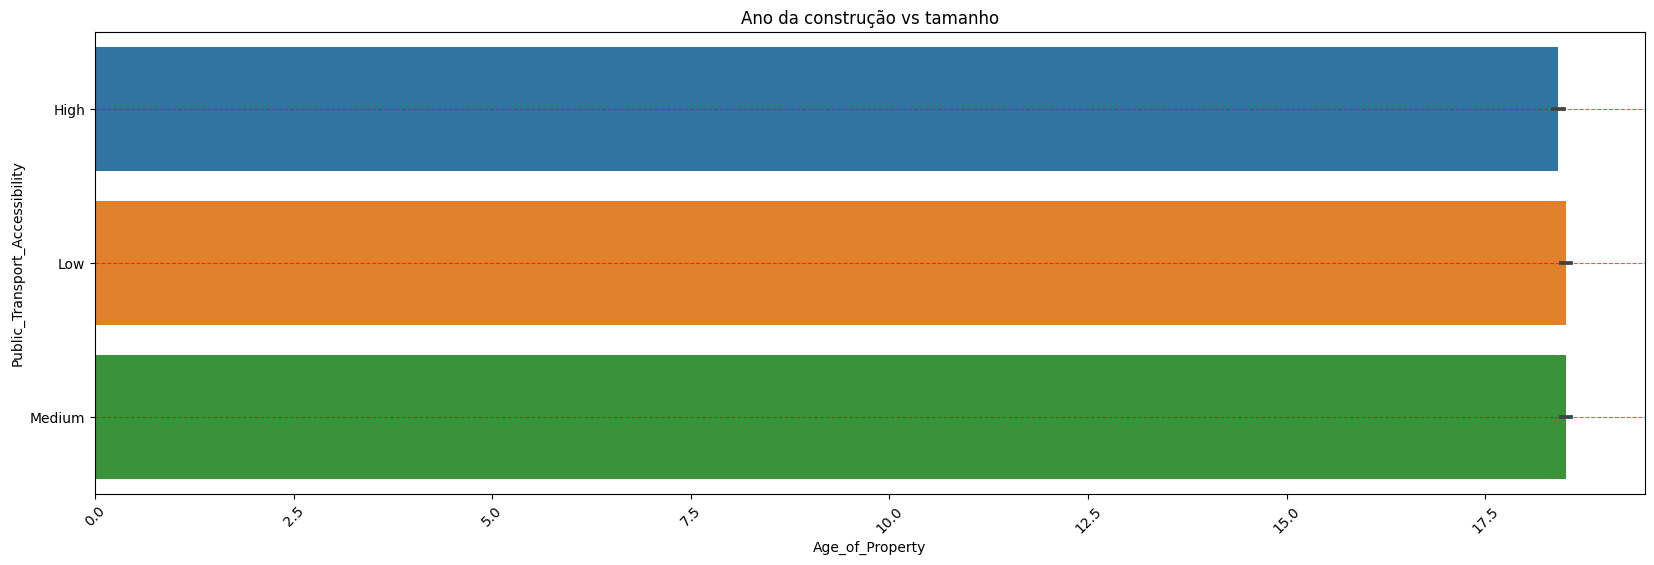

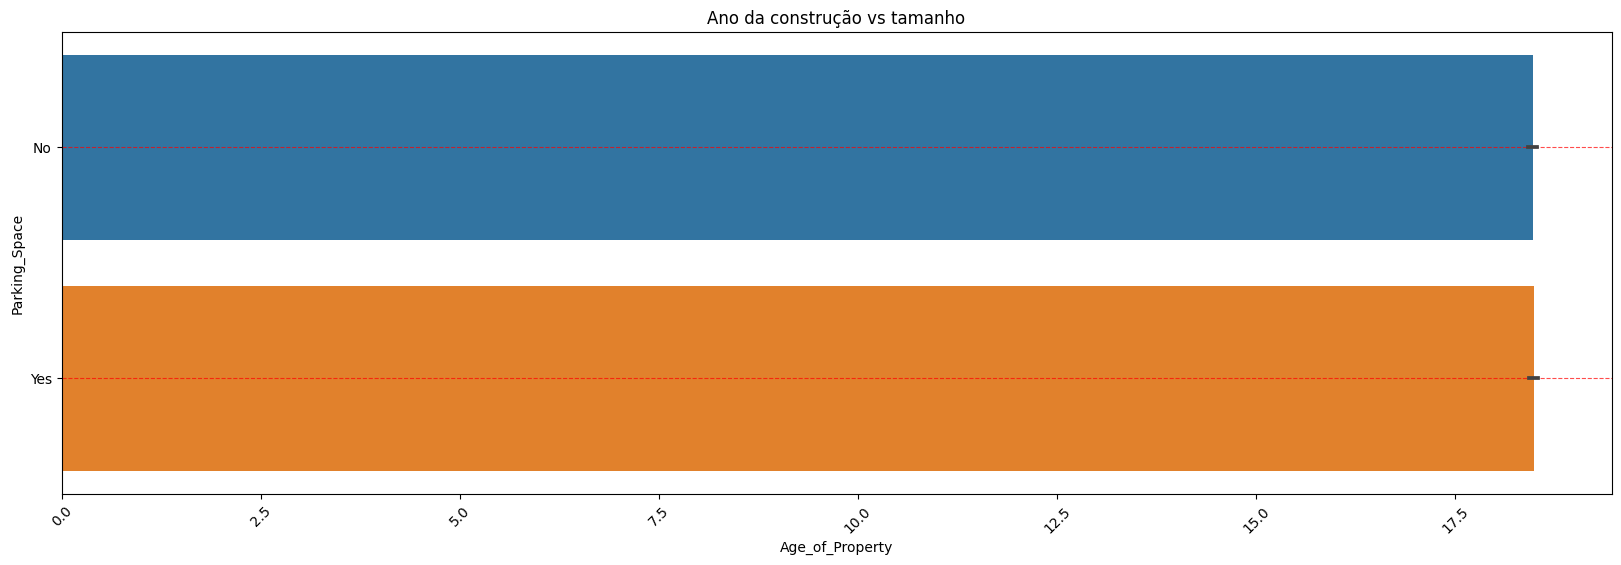

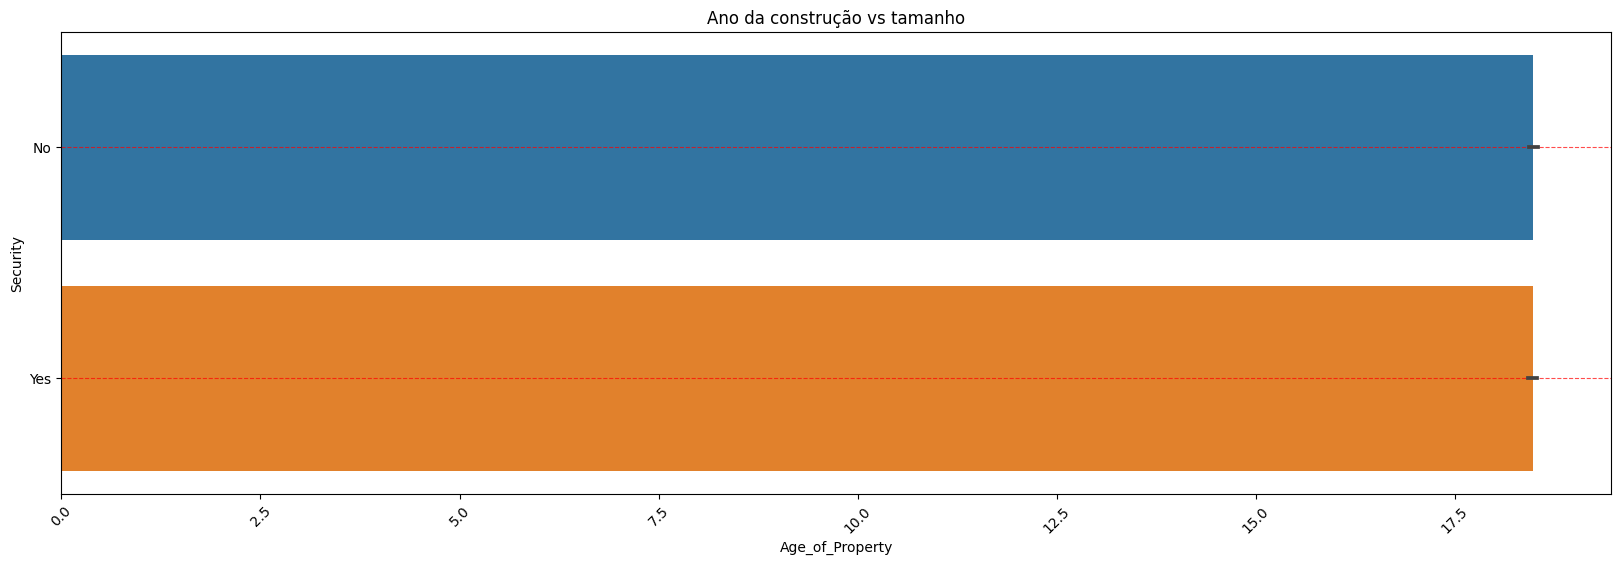

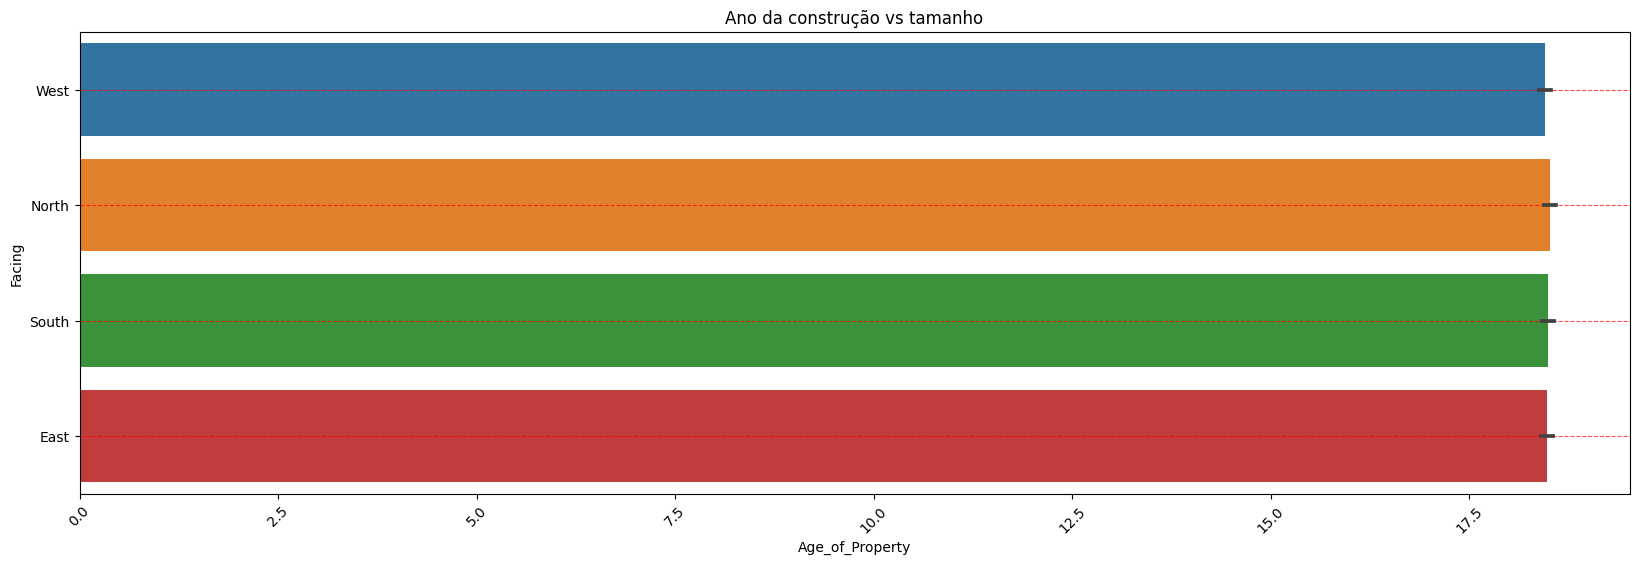

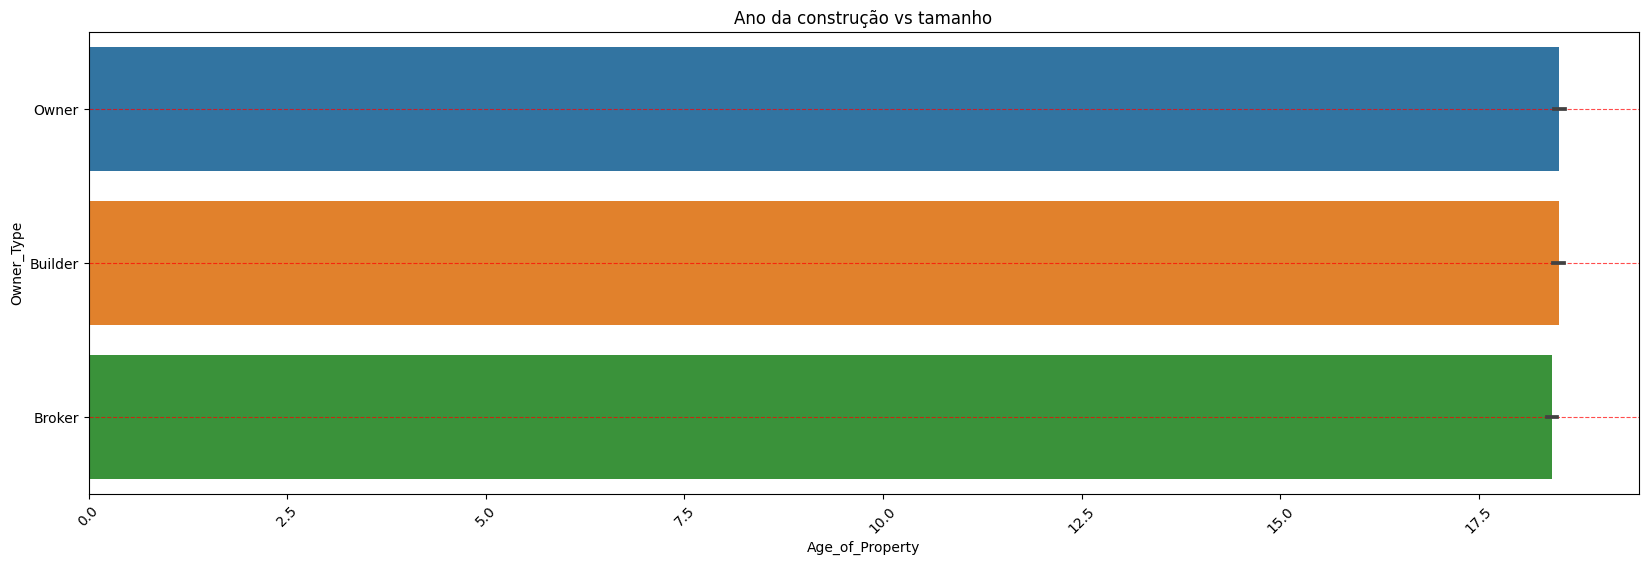

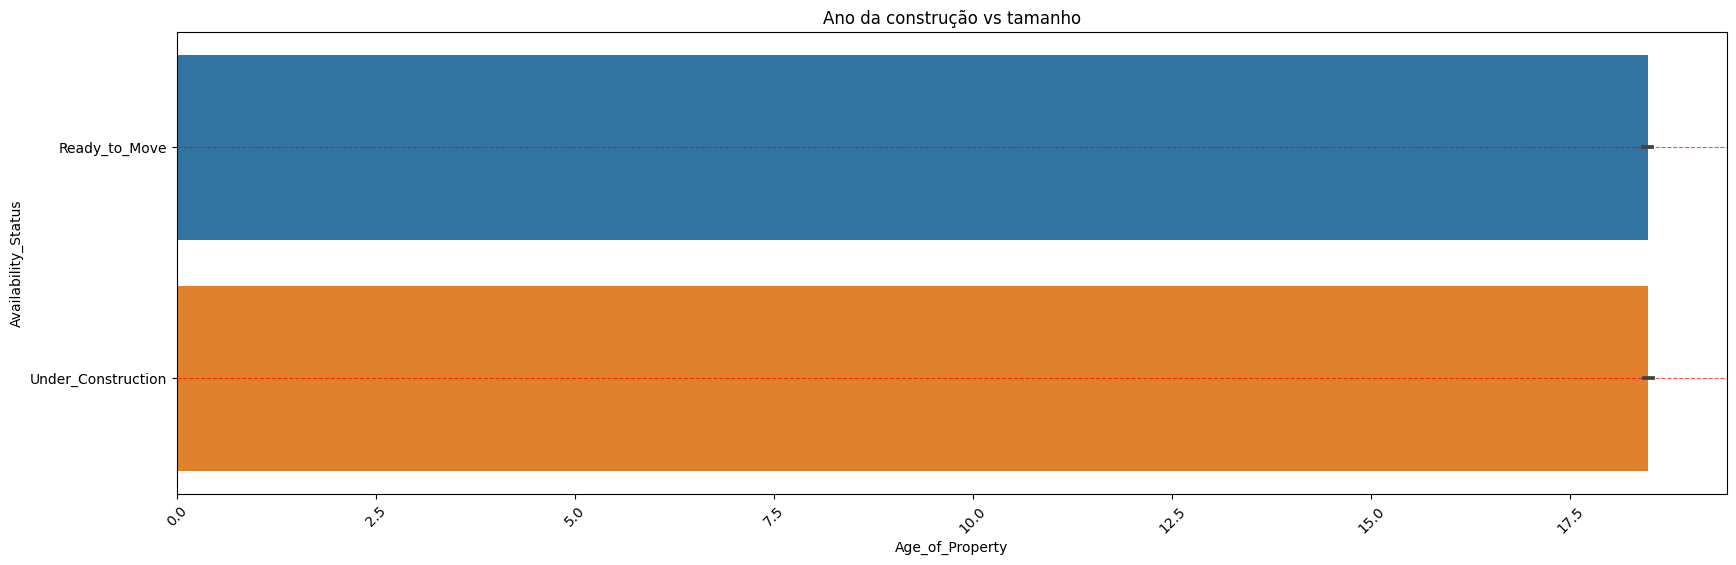

In [10]:
# Vamos percorrer a maior parte das colunas e comprar com a idade da propriedade

col_pular = ['Locality', 'Property_Type', 'Age_of_Property', 'Amenities']
for col in df_india_housing.columns:
    if col in col_pular:
        continue
    plt.figure(figsize=(20, 6))
    sns.barplot(x='Age_of_Property', y=col, data=df_india_housing)
    plt.title('Ano da construção vs tamanho')
    plt.xlabel('Age_of_Property')
    plt.ylabel(f'{col}')
    plt.xticks(rotation=45)
    plt.grid(axis='y', linestyle='--', color='red', alpha=0.7)
    plt.show()

# Informações mais detalhadas
1. Preço médio por estado
2. O tipo mais comum de propriedade
3. Os estados mais acessíveis
4. Preço médio por cidade

In [11]:
# Preço medio por estado

average_price_per_state = df_india_housing.groupby('State')['Price_in_Lakhs'].mean().sort_values(ascending=False)
print("Average Property Prices Across States:")
print(average_price_per_state)

Average Property Prices Across States:
State
Karnataka         257.408465
Tamil Nadu        256.663684
Uttar Pradesh     256.249920
Madhya Pradesh    255.961459
Gujarat           255.790061
Telangana         255.535173
Andhra Pradesh    255.197870
Bihar             254.919040
Maharashtra       254.706280
Uttarakhand       254.677234
Rajasthan         254.600214
Haryana           254.445784
Kerala            254.367332
West Bengal       254.008640
Jharkhand         253.610145
Odisha            252.838743
Punjab            252.796877
Assam             252.779235
Chhattisgarh      252.676337
Delhi             252.529900
Name: Price_in_Lakhs, dtype: float64


In [12]:
# O tipo mais comum de propriedade

most_common_property_type = df_india_housing['Property_Type'].value_counts()
print("Most Common Property Types:")
print(most_common_property_type)

Most Common Property Types:
Property_Type
Villa                83744
Independent House    83300
Apartment            82956
Name: count, dtype: int64


In [13]:
# Os estados mais acessíveis

most_affordable_states = average_price_per_state.sort_values(ascending=True)
print("Most Affordable States:")
print(most_affordable_states)

Most Affordable States:
State
Delhi             252.529900
Chhattisgarh      252.676337
Assam             252.779235
Punjab            252.796877
Odisha            252.838743
Jharkhand         253.610145
West Bengal       254.008640
Kerala            254.367332
Haryana           254.445784
Rajasthan         254.600214
Uttarakhand       254.677234
Maharashtra       254.706280
Bihar             254.919040
Andhra Pradesh    255.197870
Telangana         255.535173
Gujarat           255.790061
Madhya Pradesh    255.961459
Uttar Pradesh     256.249920
Tamil Nadu        256.663684
Karnataka         257.408465
Name: Price_in_Lakhs, dtype: float64


In [14]:
# Preço médio por cidade

average_price_by_city = df_india_housing.groupby('City')['Price_in_Lakhs'].mean().sort_values(ascending=False)
print("\nAverage Price by City:")
print(average_price_by_city.head())


Average Price by City:
City
Bangalore    258.456639
Surat        258.080467
Kochi        257.415221
Gaya         257.053391
Mangalore    256.920925
Name: Price_in_Lakhs, dtype: float64


# ML

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score

In [16]:
label_encoder = LabelEncoder()

In [17]:
categorical_columns = df_india_housing.select_dtypes(include=['object']).columns

In [18]:
for col in categorical_columns:
    df_india_housing[col] = label_encoder.fit_transform(df_india_housing[col])

In [19]:
X = df_india_housing.drop(columns=['Availability_Status'])
y = df_india_housing['Availability_Status']  # Coluna que queremos prever

In [20]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [21]:
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [22]:
y_pred = classifier.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.49788

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.54      0.52     24968
           1       0.50      0.46      0.48     25032

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000



In [24]:
print(df_india_housing['Availability_Status'].value_counts())


Availability_Status
1    125035
0    124965
Name: count, dtype: int64


In [25]:
numerical_columns = ['Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt', 'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property']

In [26]:
# Aplicando o escalonador para normalizar as variáveis numéricas
scaler = StandardScaler()
X_scaled = X.copy()
X_scaled[numerical_columns] = scaler.fit_transform(X[numerical_columns])

In [27]:
# Dividindo novamente o conjunto de dados em treino e teste
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

In [28]:
# Treinando o modelo
classifier = RandomForestClassifier(random_state=42)
classifier.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [29]:

y_pred = classifier.predict(X_test)

# Avaliando o modelo
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.4977

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.54      0.52     24968
           1       0.50      0.46      0.48     25032

    accuracy                           0.50     50000
   macro avg       0.50      0.50      0.50     50000
weighted avg       0.50      0.50      0.50     50000

